# TRAINING PROCESS OF COURT MODEL

In [ ]:
!pip install roboflow -q

import os, glob, json, shutil, time
import cv2, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/yastrebksv/TennisCourtDetector.git /content/TennisCourtDetector
import sys
sys.path.insert(0, '/content/TennisCourtDetector')

print(f"✅ Ready  |  PyTorch:{torch.__version__}  |  CUDA:{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.5 MB/s eta 0:00:00
Mounted at /content/drive
Cloning into '/content/TennisCourtDetector'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 31 (delta 1), reused 1 (delta 1), pack-reused 21 (from 2)
Receiving objects: 100% (31/31), 23.44 MiB | 19.64 MiB/s, done.
Resolving deltas: 100% (2/2), done.
✅ Ready  |  PyTorch:2.10.0+cu128  |  CUDA:True
   GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from roboflow import Roboflow

rf_a = Roboflow(api_key="mJ3rLCmuNmOJUvwWoMOq")
ds_a = rf_a.workspace("viethungpc103").project("pb-9bsin-apnne").version(4).download(
    "yolov8", location="/content/dataset_new"
)
print(f"✅ Dataset A (your labels): {ds_a.location}")

rf_b = Roboflow(api_key="mJ3rLCmuNmOJUvwWoMOq")
ds_b = rf_b.workspace("pb-rrerm").project("pb-9bsin").version(5).download(
    "yolov8", location="/content/dataset_original"
)
print(f"✅ Dataset B (original)   : {ds_b.location}")

print(f"\n📊 Raw counts:")
print(f"   A train : {len(glob.glob('/content/dataset_new/train/images/*.jpg'))}")
print(f"   B val   : {len(glob.glob('/content/dataset_original/valid/images/*.jpg'))}")
print(f"   B test  : {len(glob.glob('/content/dataset_original/test/images/*.jpg'))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_new in yolov8:: 100%|██████████| 6840/6840 [00:00<00:00, 8560.45it/s]


✅ Dataset A (your labels): /content/dataset_new
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_original in yolov8:: 100%|██████████| 7054/7054 [00:00<00:00, 9521.29it/s] 

✅ Dataset B (original)   : /content/dataset_original

📊 Raw counts:
   A train : 3350
   B val   : 407
   B test  : 200


In [ ]:
MERGED_DIR = '/content/dataset_merged'

for split in ['train', 'valid', 'test']:
    os.makedirs(f'{MERGED_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{MERGED_DIR}/{split}/labels', exist_ok=True)

def copy_split(src, dst, split):
    ci = cl = 0
    for p in glob.glob(f'{src}/{split}/images/*.jpg'):
        d = f'{dst}/{split}/images/{os.path.basename(p)}'
        if not os.path.exists(d): shutil.copy2(p, d); ci += 1
    for p in glob.glob(f'{src}/{split}/labels/*.txt'):
        d = f'{dst}/{split}/labels/{os.path.basename(p)}'
        if not os.path.exists(d): shutil.copy2(p, d); cl += 1
    return ci, cl

copy_split('/content/dataset_new',      MERGED_DIR, 'train')
copy_split('/content/dataset_original', MERGED_DIR, 'valid')
copy_split('/content/dataset_original', MERGED_DIR, 'test')

n_train = len(glob.glob(f'{MERGED_DIR}/train/images/*.jpg'))
n_val   = len(glob.glob(f'{MERGED_DIR}/valid/images/*.jpg'))
n_test  = len(glob.glob(f'{MERGED_DIR}/test/images/*.jpg'))

print(f"✅ Merged dataset:")
print(f"   Train : {n_train}  ← YOUR new labels")
print(f"   Val   : {n_val}  ← original dataset")
print(f"   Test  : {n_test}  ← original dataset")
print(f"   Total : {n_train+n_val+n_test}")

✅ Merged dataset:
   Train : 3350  ← YOUR new labels
   Val   : 407  ← original dataset
   Test  : 200  ← original dataset
   Total : 3957


In [ ]:
OUT_W, OUT_H = 640, 360
os.makedirs('/content/dataset_tracknet/images', exist_ok=True)

def convert_split(split, img_dir, lbl_dir, prefix):
    data    = []
    skipped = 0
    for img_path in sorted(glob.glob(f'{img_dir}/*.jpg')):
        name     = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = f'{lbl_dir}/{name}.txt'
        out_name = f'{prefix}_{name}'

        img = cv2.imread(img_path)
        if img is None: skipped += 1; continue
        cv2.imwrite(
            f'/content/dataset_tracknet/images/{out_name}.png',
            cv2.resize(img, (OUT_W, OUT_H))
        )

        if not os.path.exists(lbl_path): skipped += 1; continue
        with open(lbl_path) as f:
            line = f.readline().strip()
        if not line: skipped += 1; continue

        parts   = line.split()
        kp_data = parts[5:]
        if len(kp_data) < 36: skipped += 1; continue

        kps = []
        for k in range(12):
            x_norm = float(kp_data[k*3])
            y_norm = float(kp_data[k*3+1])
            v      = float(kp_data[k*3+2])
            kps.append([x_norm*OUT_W, y_norm*OUT_H] if v > 0 else [-1.0, -1.0])

        data.append({'id': out_name, 'kps': kps})

    print(f"  {split:>5}: {len(data):>5} converted  |  {skipped} skipped")
    return data

print("Converting merged dataset to PickleballCourtNet format...")

train_data = convert_split(
    'train',
    f'{MERGED_DIR}/train/images',
    f'{MERGED_DIR}/train/labels',
    prefix='train'
)

val_data = convert_split(
    'val',
    f'{MERGED_DIR}/valid/images',
    f'{MERGED_DIR}/valid/labels',
    prefix='val'
)

with open('/content/dataset_tracknet/data_train.json', 'w') as f:
    json.dump(train_data, f)
with open('/content/dataset_tracknet/data_val.json', 'w') as f:
    json.dump(val_data, f)

print(f"\n✅ Conversion done")
print(f"   Train : {len(train_data)} samples  (YOUR new labels)")
print(f"   Val   : {len(val_data)} samples  (original dataset)")

Converting merged dataset to PickleballCourtNet format...
  train:  3347 converted  |  3 skipped
    val:   407 converted  |  0 skipped

✅ Conversion done
   Train : 3347 samples  (YOUR new labels)
   Val   : 407 samples  (original dataset)


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, pad=1, stride=1, bias=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=pad, bias=bias),
            nn.ReLU(),
            nn.BatchNorm2d(out_channels)
        )
    def forward(self, x): return self.block(x)

class PickleballCourtNet(nn.Module):
    def __init__(self, out_channels=13):
        super().__init__()
        self.out_channels = out_channels
        self.conv1  = ConvBlock(3,   64);  self.conv2  = ConvBlock(64,  64)
        self.pool1  = nn.MaxPool2d(2, 2)
        self.conv3  = ConvBlock(64,  128); self.conv4  = ConvBlock(128, 128)
        self.pool2  = nn.MaxPool2d(2, 2)
        self.conv5  = ConvBlock(128, 256); self.conv6  = ConvBlock(256, 256)
        self.conv7  = ConvBlock(256, 256)
        self.pool3  = nn.MaxPool2d(2, 2)
        self.conv8  = ConvBlock(256, 512); self.conv9  = ConvBlock(512, 512)
        self.conv10 = ConvBlock(512, 512)
        self.ups1   = nn.Upsample(scale_factor=2)
        self.conv11 = ConvBlock(512, 256); self.conv12 = ConvBlock(256, 256)
        self.conv13 = ConvBlock(256, 256)
        self.ups2   = nn.Upsample(scale_factor=2)
        self.conv14 = ConvBlock(256, 128); self.conv15 = ConvBlock(128, 128)
        self.ups3   = nn.Upsample(scale_factor=2)
        self.conv16 = ConvBlock(128, 64);  self.conv17 = ConvBlock(64,  64)
        self.conv18 = ConvBlock(64,  self.out_channels)
        self._init_weights()

    def forward(self, x):
        x = self.conv1(x);  x = self.conv2(x);  x = self.pool1(x)
        x = self.conv3(x);  x = self.conv4(x);  x = self.pool2(x)
        x = self.conv5(x);  x = self.conv6(x);  x = self.conv7(x)
        x = self.pool3(x)
        x = self.conv8(x);  x = self.conv9(x);  x = self.conv10(x)
        x = self.ups1(x);   x = self.conv11(x); x = self.conv12(x); x = self.conv13(x)
        x = self.ups2(x);   x = self.conv14(x); x = self.conv15(x)
        x = self.ups3(x);   x = self.conv16(x); x = self.conv17(x); x = self.conv18(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.uniform_(m.weight, -0.05, 0.05)
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = PickleballCourtNet(out_channels=13).to(device)
out    = model(torch.rand(1, 3, 360, 640).to(device))
print(f"✅ PickleballCourtNet ready")
print(f"   Output : {tuple(out.shape)}")
print(f"   Params : {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"   Device : {device}")

✅ PickleballCourtNet ready
   Output : (1, 13, 360, 640)
   Params : 10.6M
   Device : cuda


In [ ]:
def draw_gaussian(heatmap, cx, cy, radius):
    H, W     = heatmap.shape
    diameter = 2*radius+1; sigma = diameter/6.0
    x        = np.arange(0, diameter, 1, np.float32)
    y        = x[:, np.newaxis]
    x0, y0   = diameter//2, diameter//2
    gaussian = np.exp(-((x-x0)**2+(y-y0)**2)/(2*sigma**2))
    left=min(cx,radius);   right=min(W-cx,radius+1)
    top =min(cy,radius);   bottom=min(H-cy,radius+1)
    g_l=radius-left;       g_r=radius+right
    g_t=radius-top;        g_b=radius+bottom
    if g_r>g_l and g_b>g_t and right>0 and bottom>0:
        heatmap[cy-top:cy+bottom, cx-left:cx+right] = np.maximum(
            heatmap[cy-top:cy+bottom, cx-left:cx+right],
            gaussian[g_t:g_b, g_l:g_r]
        )

class PickleballCourtDataset(Dataset):
    OUT_H=360; OUT_W=640; HP_RADIUS=55

    def __init__(self, mode, data_dir='/content/dataset_tracknet'):
        assert mode in ['train','val']
        self.img_dir = os.path.join(data_dir, 'images')
        with open(os.path.join(data_dir, f'data_{mode}.json')) as f:
            self.data = json.load(f)
        print(f"  {mode}: {len(self.data)} samples")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        kps    = sample['kps']
        img    = cv2.imread(os.path.join(self.img_dir, sample['id']+'.png'))
        if img is None: img = np.zeros((self.OUT_H,self.OUT_W,3),np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        inp = np.rollaxis(img.astype(np.float32)/255.0, 2, 0)

        heatmaps  = np.zeros((13,self.OUT_H,self.OUT_W), dtype=np.float32)
        visible   = []
        for k,(x,y) in enumerate(kps):
            if x>=0 and y>=0:
                xi=np.clip(int(round(x)),0,self.OUT_W-1)
                yi=np.clip(int(round(y)),0,self.OUT_H-1)
                draw_gaussian(heatmaps[k],xi,yi,self.HP_RADIUS)
                visible.append((xi,yi))
            else:
                visible.append(None)

        p0,p2,p9,p11 = visible[0],visible[2],visible[9],visible[11]
        if all(p is not None for p in [p0,p2,p9,p11]):
            try:
                x1,y1=p0; x2,y2=p9; x3,y3=p2; x4,y4=p11
                denom=(x1-x2)*(y3-y4)-(y1-y2)*(x3-x4)
                if abs(denom)>1e-6:
                    t=((x1-x3)*(y3-y4)-(y1-y3)*(x3-x4))/denom
                    cx=np.clip(int(x1+t*(x2-x1)),0,self.OUT_W-1)
                    cy=np.clip(int(y1+t*(y2-y1)),0,self.OUT_H-1)
                    draw_gaussian(heatmaps[12],cx,cy,self.HP_RADIUS)
            except: pass

        return (torch.FloatTensor(inp),
                torch.FloatTensor(heatmaps),
                np.array(kps,dtype=np.float32),
                sample['id'])

print("Building datasets...")
train_ds = PickleballCourtDataset('train')
val_ds   = PickleballCourtDataset('val')
inp,hm,kps,name = train_ds[0]
print(f"\n✅ Dataset ready")
print(f"   Train input : {tuple(inp.shape)}")
print(f"   Heatmap     : {tuple(hm.shape)}")

Building datasets...
  train: 3347 samples
  val: 407 samples

✅ Dataset ready
   Train input : (3, 360, 640)
   Heatmap     : (13, 360, 640)


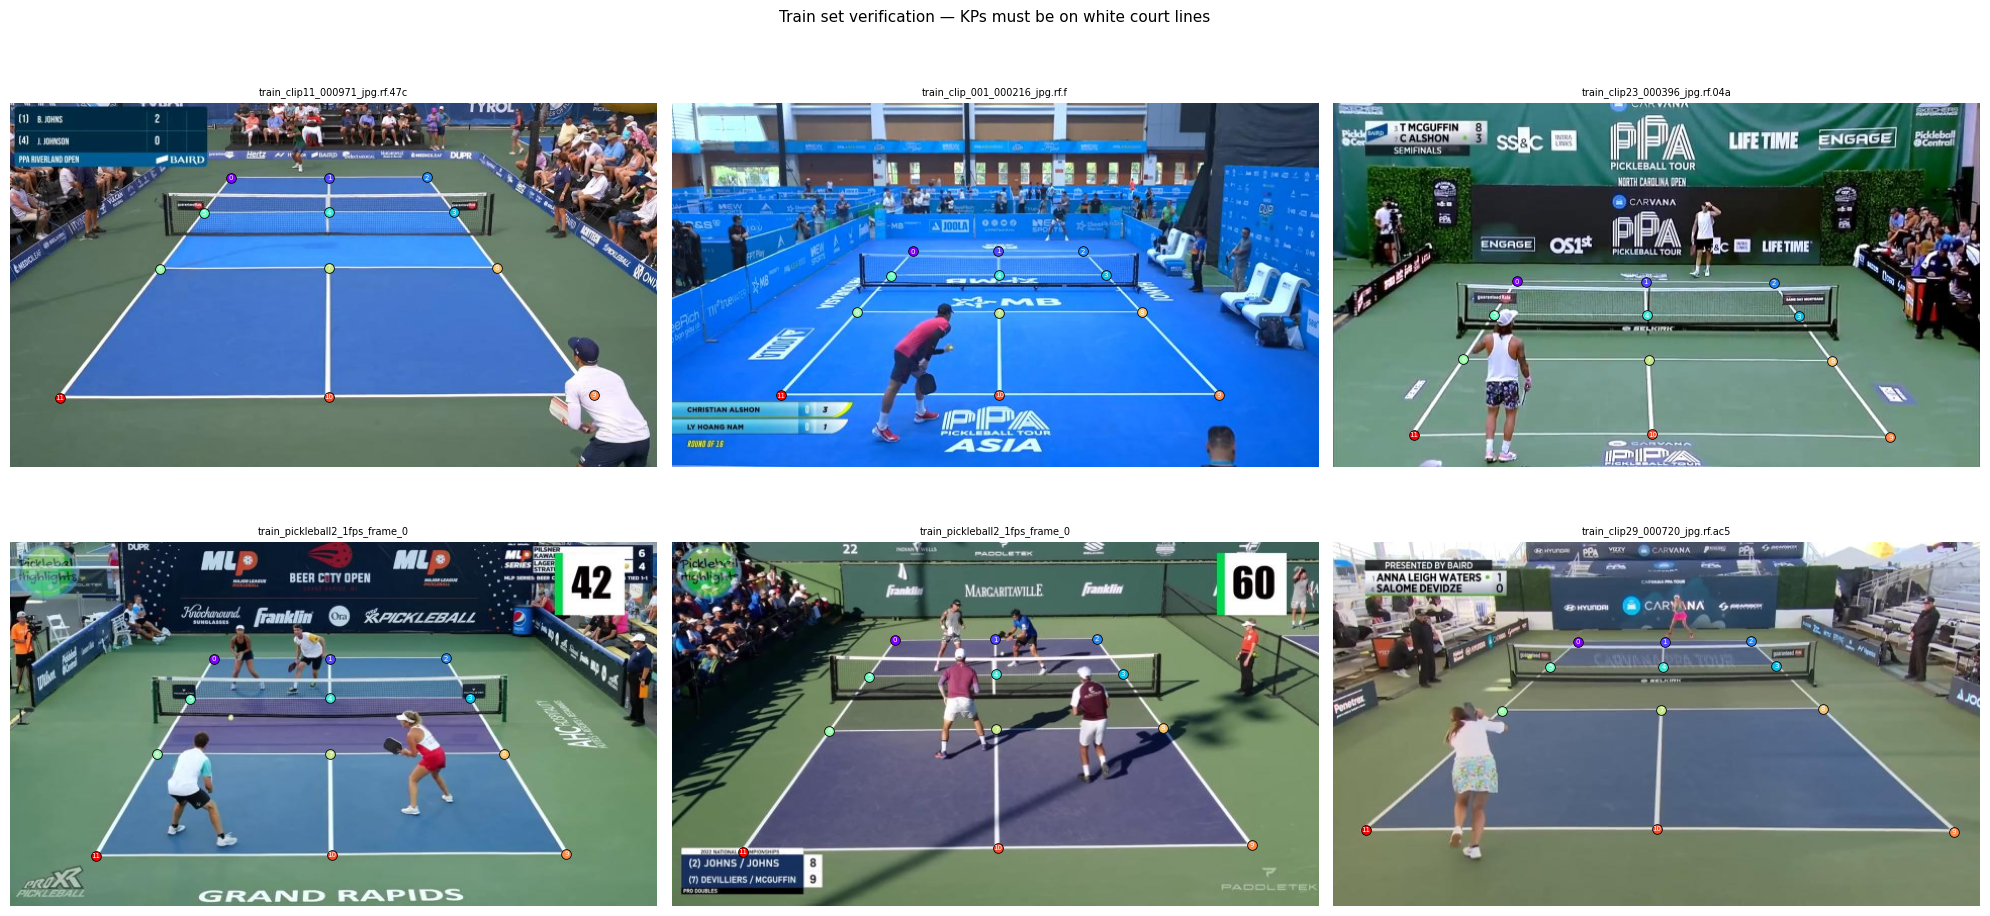

✅ Check every dot lands on a court line intersection


In [ ]:
import random
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
colors    = plt.cm.rainbow(np.linspace(0, 1, 12))

indices = random.sample(range(len(train_ds)), 6)
for ax, idx in zip(axes.flatten(), indices):
    inp, hm, kps, name = train_ds[idx]
    img = inp.numpy().transpose(1,2,0)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{name[:30]}', fontsize=7)
    for k,(x,y) in enumerate(kps):
        if x>=0 and y>=0:
            ax.plot(x,y,'o',color=colors[k],ms=7,mec='black',mew=0.6)
            ax.annotate(str(k),(x,y),fontsize=5,
                        color='white',ha='center',va='center')

plt.suptitle('Train set verification — KPs must be on white court lines',
             fontsize=11)
plt.tight_layout()
os.makedirs('/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2',
            exist_ok=True)
plt.savefig('/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/dataset_verify.png',
            dpi=100)
plt.show()
print("✅ Check every dot lands on a court line intersection")

In [ ]:
SAVE_DIR   = '/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2'
EPOCHS     = 100
BATCH      = 8
LR         = 1e-5
EARLY_STOP = 5
os.makedirs(SAVE_DIR, exist_ok=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=4, pin_memory=True)

model     = PickleballCourtNet(out_channels=13).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def extract_kps(hm_batch):
    B,C,H,W = hm_batch.shape
    flat = hm_batch[:,:12].reshape(B,12,-1)
    idx  = flat.argmax(dim=2)
    return torch.stack([(idx%W).float(),(idx//W).float()],dim=2)

def compute_acc(pred_hm, gt_kps, thr=7):
    pred = extract_kps(pred_hm.cpu()).numpy()
    gt   = gt_kps.numpy()
    total = correct = 0
    for b in range(pred.shape[0]):
        for k in range(12):
            gx,gy = gt[b,k]
            if gx<0 or gy<0: continue
            total+=1; correct+=int(np.hypot(pred[b,k,0]-gx,pred[b,k,1]-gy)<=thr)
    return correct/max(total,1)

best_acc=0.0; patience_count=0; history=[]; t0=time.time()

print("="*85)
print(f"  PickleballCourtNet — Train:YOUR({len(train_ds)}) | Val:Original({len(val_ds)})")
print(f"  Epochs:{EPOCHS}  Batch:{BATCH}  LR:{LR}  EarlyStop:{EARLY_STOP}")
print("="*85)
print(f"{'Epoch':>7}  {'TrLoss':>9}  {'ValLoss':>9}  {'Acc@7px':>9}  {'Time':>7}  {'Note':>12}")
print("-"*85)

for epoch in range(1, EPOCHS+1):
    ep_t = time.time()

    model.train()
    tr_loss=0.0
    for imgs,hms,_,_ in train_loader:
        imgs=imgs.to(device); hms=hms.to(device)
        optimizer.zero_grad()
        loss=criterion(model(imgs),hms)
        loss.backward(); optimizer.step()
        tr_loss+=loss.item()
    tr_loss/=len(train_loader)

    model.eval(); vl_loss=vl_acc=0.0
    with torch.no_grad():
        for imgs,hms,kps,_ in val_loader:
            imgs=imgs.to(device); hms=hms.to(device)
            pred=model(imgs)
            vl_loss+=criterion(pred,hms).item()
            vl_acc +=compute_acc(pred,kps,thr=7)
    vl_loss/=len(val_loader); vl_acc/=len(val_loader)
    scheduler.step()

    history.append({'epoch':epoch,'tr_loss':tr_loss,
                    'vl_loss':vl_loss,'vl_acc':vl_acc})

    is_best = vl_acc > best_acc
    if is_best:
        best_acc=vl_acc; patience_count=0
        torch.save(model.state_dict(), f'{SAVE_DIR}/best.pt')
        note="✅ BEST"
    else:
        patience_count+=1
        note=f"({patience_count}/{EARLY_STOP})"

    print(f"{epoch:>4}/{EPOCHS:<3}  {tr_loss:>9.5f}  {vl_loss:>9.5f}  "
          f"{vl_acc:>9.4f}  {time.time()-ep_t:>5.0f}s  {note}")

    if epoch%10==0:
        torch.save({'epoch':epoch,'model_state':model.state_dict(),
                    'best_acc':best_acc,'history':history},
                   f'{SAVE_DIR}/ckpt_epoch{epoch}.pt')
        print(f"  💾 Checkpoint saved → epoch {epoch}")

    if patience_count>=EARLY_STOP:
        print(f"\n⚠️  Early stopping at epoch {epoch}"); break

torch.save(model.state_dict(), f'{SAVE_DIR}/last.pt')
with open(f'{SAVE_DIR}/history.json','w') as f:
    json.dump(history, f, indent=2)

print(f"\n✅ Training done")
print(f"   Best Acc@7px : {best_acc:.4f}")
print(f"   Best weights : {SAVE_DIR}/best.pt")

  PickleballCourtNet — Train:YOUR(3347) | Val:Original(407)
  Epochs:100  Batch:8  LR:1e-05  EarlyStop:5
  Epoch     TrLoss    ValLoss    Acc@7px     Time          Note
-------------------------------------------------------------------------------------
   1/100    0.91338    0.96670     0.6985     88s  ✅ BEST
   2/100    0.86692    0.87988     0.8183     87s  ✅ BEST
   3/100    0.85589    0.86377     0.8824     87s  ✅ BEST
   4/100    0.84679    0.86796     0.9180     87s  ✅ BEST
   5/100    0.83833    0.83150     0.9341     87s  ✅ BEST
   6/100    0.83212    0.84681     0.9374     87s  ✅ BEST
   7/100    0.82811    0.84463     0.9433     87s  ✅ BEST
   8/100    0.82413    0.81911     0.9480     87s  ✅ BEST
   9/100    0.82020    0.82252     0.9507     87s  ✅ BEST
  10/100    0.81628    0.81449     0.9595     87s  ✅ BEST
  💾 Checkpoint saved → epoch 10
  11/100    0.81331    0.82274     0.9628     87s  ✅ BEST
  12/100    0.81135    0.81529     0.9626     87s  (1/5)
  13/100    0.8094

In [ ]:
ep      = [h['epoch']   for h in history]
tr_loss = [h['tr_loss'] for h in history]
vl_loss = [h['vl_loss'] for h in history]
vl_acc  = [h['vl_acc']  for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, tr_loss, label='Train', color='steelblue', lw=1.5)
axes[0].plot(ep, vl_loss, label='Val',   color='tomato',    lw=1.5)
axes[0].set_title('MSE Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, vl_acc, color='green', lw=2)
axes[1].axhline(0.95, color='red', ls='--', alpha=0.5, label='Target 0.95')
axes[1].set_title('Val Accuracy @ 7px'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    f'PickleballCourtNet v2\n'
    f'Train: YOUR labels ({len(train_ds)}) | Val: Original ({len(val_ds)})',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120)
plt.show()
best_ep = ep[np.argmax(vl_acc)]
print(f"✅ Best Acc@7px: {max(vl_acc):.4f} @ epoch {best_ep}")

✅ Post-processing functions defined


In [ ]:
try:
    import cv2.ximgproc
    HAS_XIMGPROC = True
except Exception:
    HAS_XIMGPROC = False

print(f"ximgproc: {'✅' if HAS_XIMGPROC else '❌ fallback'}")

REF_KPS = np.array([
    [  0,1372],[305,1372],[610,1372],
    [610, 915],[305, 915],[  0, 915],
    [  0, 457],[305, 457],[610, 457],
    [610,   0],[305,   0],[  0,   0],
], dtype=np.float32)

CONFIGS = [
    [0,2,9,11],[0,2,6,8],[0,2,3,5],[6,8,9,11],
    [0,5,6,11],[2,3,8,9],[1,7,10,4],[0,1,9,10],
    [1,2,10,9],[0,2,1,10],[3,5,6,8],[0,11,2,9],
]

def skeletonize(binary):
    if HAS_XIMGPROC:
        b = (binary>0).astype(np.uint8)*255
        return cv2.ximgproc.thinning(b,thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
    binary_u8=( binary>0).astype(np.uint8)*255
    skeleton=np.zeros_like(binary_u8)
    element=cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
    temp=binary_u8.copy()
    while True:
        eroded=cv2.erode(temp,element); opened=cv2.dilate(eroded,element)
        skeleton=cv2.bitwise_or(skeleton,cv2.subtract(temp,opened))
        temp=eroded.copy()
        if cv2.countNonZero(temp)==0: break
    return skeleton

def refine_kps_classical_cv(frame_bgr, kps, crop_radius=40):
    H_f,W_f=frame_bgr.shape[:2]
    refined_kps=kps.copy().astype(float)
    refined_mask=np.zeros(len(kps),dtype=bool)
    for k in range(len(kps)):
        px,py=kps[k]
        if px<0 or py<0: continue
        cx=int(round(px)); cy=int(round(py))
        cx1=max(0,cx-crop_radius); cy1=max(0,cy-crop_radius)
        cx2=min(W_f-1,cx+crop_radius); cy2=min(H_f-1,cy+crop_radius)
        if (cx2-cx1)<10 or (cy2-cy1)<10: continue
        crop=frame_bgr[cy1:cy2,cx1:cx2]
        hsv=cv2.cvtColor(crop,cv2.COLOR_BGR2HSV)
        white_mask=cv2.inRange(hsv,np.array([0,0,160]),np.array([180,60,255]))
        green_mask=cv2.inRange(hsv,np.array([30,30,30]),np.array([90,255,255]))
        white_mask[green_mask>0]=0
        skeleton=skeletonize(white_mask)
        lines=cv2.HoughLinesP(skeleton,1,np.pi/180,threshold=15,
                               minLineLength=10,maxLineGap=10)
        if lines is None or len(lines)<2: continue
        h_lines,v_lines=[],[]
        for ln in lines:
            lx1,ly1,lx2,ly2=ln[0]
            angle=abs(np.degrees(np.arctan2(ly2-ly1,lx2-lx1)))
            if angle<30 or angle>150: h_lines.append(ln[0])
            elif 60<angle<120:        v_lines.append(ln[0])
        if not h_lines or not v_lines: continue
        ccx,ccy=crop.shape[1]//2,crop.shape[0]//2
        best_pt,best_d=None,float('inf')
        for hl in h_lines:
            for vl in v_lines:
                hl_x1,hl_y1,hl_x2,hl_y2=hl; vl_x1,vl_y1,vl_x2,vl_y2=vl
                denom=(hl_x1-hl_x2)*(vl_y1-vl_y2)-(hl_y1-hl_y2)*(vl_x1-vl_x2)
                if abs(denom)<1e-6: continue
                t=((hl_x1-vl_x1)*(vl_y1-vl_y2)-(hl_y1-vl_y1)*(vl_x1-vl_x2))/denom
                ix=hl_x1+t*(hl_x2-hl_x1); iy=hl_y1+t*(hl_y2-hl_y1)
                if not (0<=ix<crop.shape[1] and 0<=iy<crop.shape[0]): continue
                xi,yi=int(round(ix)),int(round(iy))
                roi=white_mask[max(0,yi-3):yi+4,max(0,xi-3):xi+4]
                if not np.any(roi>0): continue
                d=np.hypot(ix-ccx,iy-ccy)
                if d<best_d: best_d,best_pt=d,(ix,iy)
        if best_pt is not None:
            rx=cx1+best_pt[0]; ry=cy1+best_pt[1]
            if np.hypot(rx-cx,ry-cy)<crop_radius*0.9:
                refined_kps[k]=[rx,ry]; refined_mask[k]=True
    return refined_kps, refined_mask

def get_trans_matrix_pickleball(kps):
    visible={k:kps[k] for k in range(12) if kps[k][0]>=0 and kps[k][1]>=0}
    if len(visible)<4: return None
    best_H,best_err=None,float('inf')
    for conf in CONFIGS:
        if not all(c in visible for c in conf): continue
        src=np.float32([REF_KPS[c] for c in conf])
        dst=np.float32([kps[c]     for c in conf])
        H,_=cv2.findHomography(src,dst,method=0)
        if H is None: continue
        proj=cv2.perspectiveTransform(REF_KPS.reshape(-1,1,2),H).reshape(-1,2)
        errs=[np.hypot(visible[k][0]-proj[k][0],visible[k][1]-proj[k][1])
              for k in visible if k not in conf]
        if not errs: continue
        mean_err=np.mean(errs)
        if mean_err<best_err: best_err,best_H=mean_err,H
    return best_H

def apply_homography_correction(kps, H):
    if H is None: return kps.copy()
    proj=cv2.perspectiveTransform(REF_KPS.reshape(-1,1,2),H).reshape(-1,2)
    corrected=kps.copy().astype(float)
    for k in range(12):
        if kps[k][0]<0 or kps[k][1]<0:
            corrected[k]=proj[k]
        else:
            dist=np.hypot(kps[k][0]-proj[k][0],kps[k][1]-proj[k][1])
            if dist>15: corrected[k]=proj[k]
    return corrected

print("✅ Post-processing functions ready")

✅ Inference pipeline defined


In [ ]:
def predict_keypoints(model, frame_bgr, device,
                       apply_refine=True, apply_homography=True):
    H_orig,W_orig = frame_bgr.shape[:2]
    MODEL_H,MODEL_W = 360,640
    img = cv2.resize(frame_bgr,(MODEL_W,MODEL_H))
    inp = cv2.cvtColor(img,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    inp = torch.FloatTensor(inp.transpose(2,0,1)).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        hm = model(inp)
    hm_np = hm[0,:12].cpu().numpy()
    kps   = np.zeros((12,2),dtype=np.float32)
    for k in range(12):
        flat_idx = hm_np[k].argmax()
        kps[k]   = [int(flat_idx%MODEL_W)*W_orig/MODEL_W,
                    int(flat_idx//MODEL_W)*H_orig/MODEL_H]
    if apply_refine:
        kps,_ = refine_kps_classical_cv(frame_bgr, kps, crop_radius=40)
    if apply_homography:
        H_mat = get_trans_matrix_pickleball(kps)
        kps   = apply_homography_correction(kps, H_mat)
    return kps

SKELETON = [
    (0,1),(1,2),(3,4),(4,5),(6,7),(7,8),(9,10),(10,11),
    (0,5),(2,3),(5,6),(3,8),(6,11),(8,9),(1,4),(4,7),(7,10),
]
print("✅ Inference function ready")

✅ Loaded: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet/best.pt


UnboundLocalError: cannot access local variable 'cv2' where it is not associated with a value

In [ ]:
VIDEO_PATH = '/content/drive/MyDrive/In_Out_Pickleball/conversial_call/first.mp4'
BEST_PT    = f'{SAVE_DIR}/best.pt'

model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()
print(f"✅ Loaded: {BEST_PT}")

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ret, frame = cap.read()
cap.release()
assert ret, "Could not read frame"

kps_raw  = predict_keypoints(model,frame,device,apply_refine=False,apply_homography=False)
kps_ref  = predict_keypoints(model,frame,device,apply_refine=True, apply_homography=False)
kps_full = predict_keypoints(model,frame,device,apply_refine=True, apply_homography=True)

rgb        = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
colors_plt = plt.cm.rainbow(np.linspace(0,1,12))
fig, axes  = plt.subplots(1,3,figsize=(24,8))

for ax,kps,title in [
    (axes[0],kps_raw, 'Stage 1: Raw heatmap argmax'),
    (axes[1],kps_ref, 'Stage 2: + Classical CV refinement'),
    (axes[2],kps_full,'Stage 3: + Homography correction'),
]:
    ax.imshow(rgb); ax.axis('off'); ax.set_title(title,fontsize=10)
    for (i,j) in SKELETON:
        ax.plot([kps[i][0],kps[j][0]],[kps[i][1],kps[j][1]],
                '-',color='white',lw=0.8,alpha=0.6)
    for k in range(12):
        x,y=kps[k]
        ax.plot(x,y,'o',color=colors_plt[k],ms=8,mec='black',mew=0.7)
        ax.annotate(str(k),(x,y),fontsize=6,color='white',ha='center',va='center')

plt.suptitle('PickleballCourtNet v2 — 3-stage pipeline', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/test_frame60.png', dpi=120)
plt.show()
print(f"✅ Saved: {SAVE_DIR}/test_frame60.png")

In [ ]:
OUTPUT_PATH = f'{SAVE_DIR}/court_tracknet_v2.mp4'
EMA_ALPHA   = 0.15

model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()

cap   = cv2.VideoCapture(VIDEO_PATH)
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_v   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

writer = cv2.VideoWriter(OUTPUT_PATH,
                         cv2.VideoWriter_fourcc(*'mp4v'),
                         FPS, (W,H_v))

print(f"📹 {W}x{H_v} @ {FPS:.1f}fps — {TOTAL} frames")
print(f"💾 Output → {OUTPUT_PATH}\n")

smoothed=None; frame_idx=0

while True:
    ret,frame=cap.read()
    if not ret: break
    frame_idx+=1

    kps = predict_keypoints(model,frame,device,
                             apply_refine=True,apply_homography=True)

    if smoothed is None: smoothed=kps.copy().astype(float)
    else: smoothed=EMA_ALPHA*kps+(1-EMA_ALPHA)*smoothed

    vis=frame.copy()
    for (i,j) in SKELETON:
        cv2.line(vis,(int(smoothed[i][0]),int(smoothed[i][1])),
                      (int(smoothed[j][0]),int(smoothed[j][1])),
                 (255,255,255),1,cv2.LINE_AA)
    for k in range(12):
        x,y=int(smoothed[k][0]),int(smoothed[k][1])
        cv2.circle(vis,(x,y),7,(0,0,255),-1,cv2.LINE_AA)
        cv2.circle(vis,(x,y),7,(0,0,  0), 1,cv2.LINE_AA)
        cv2.putText(vis,str(k),(x-4,y+4),
                    cv2.FONT_HERSHEY_SIMPLEX,0.30,(255,255,255),1,cv2.LINE_AA)

    cv2.rectangle(vis,(0,0),(W,34),(0,0,0),-1)
    cv2.putText(vis,f"Frame {frame_idx}/{TOTAL}  |  PickleballCourtNet v2",
                (10,22),cv2.FONT_HERSHEY_SIMPLEX,0.60,(0,255,0),2,cv2.LINE_AA)

    writer.write(vis)
    if frame_idx%100==0:
        print(f"  Frame {frame_idx:>5}/{TOTAL}")

cap.release(); writer.release()
print(f"\n✅ Done — {frame_idx} frames")
print(f"   Output: {OUTPUT_PATH}")

# End to End test Video

In [ ]:
!pip install opencv-contrib-python-headless -q

import cv2, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt, os
from collections import deque
from google.colab import drive
drive.mount('/content/drive')

HAS_XIMGPROC = False
try:
    import cv2.ximgproc
    _ = cv2.ximgproc.thinning
    HAS_XIMGPROC = True
    print("✅ ximgproc available")
except Exception:
    print("⚠️  ximgproc fallback mode")

print(f"✅ Ready  |  CUDA:{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 35.3 MB/s eta 0:00:00
Mounted at /content/drive
✅ ximgproc available
✅ Ready  |  CUDA:True
   GPU: NVIDIA L4


In [ ]:
BEST_PT     = '/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt'
VIDEO_PATH  = '/content/drive/MyDrive/In_Out_Pickleball/controversial_call/second.mp4'
OUTPUT_PATH = '/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized.mp4'

BUFFER_SIZE  = 8
MOVE_THRESH  = 6
EMA_ALPHA    = 0.05
CROP_RADIUS  = 40

print(f"✅ Config loaded")
print(f"   Model       : {BEST_PT}")
print(f"   Video       : {VIDEO_PATH}")
print(f"   Output      : {OUTPUT_PATH}")
print(f"   Buffer size : {BUFFER_SIZE} frames")
print(f"   Move thresh : {MOVE_THRESH} px")
print(f"   EMA alpha   : {EMA_ALPHA}")

✅ Config loaded
   Model       : /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt
   Video       : /content/drive/MyDrive/In_Out_Pickleball/controversial_call/second.mp4
   Output      : /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized.mp4
   Buffer size : 8 frames
   Move thresh : 6 px
   EMA alpha   : 0.05


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1, s=1, bias=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p, bias=bias),
            nn.ReLU(), nn.BatchNorm2d(out_ch)
        )
    def forward(self, x): return self.block(x)

class PickleballCourtNet(nn.Module):
    def __init__(self, out_channels=13):
        super().__init__()
        self.conv1  = ConvBlock(3,   64);  self.conv2  = ConvBlock(64,  64)
        self.pool1  = nn.MaxPool2d(2, 2)
        self.conv3  = ConvBlock(64,  128); self.conv4  = ConvBlock(128, 128)
        self.pool2  = nn.MaxPool2d(2, 2)
        self.conv5  = ConvBlock(128, 256); self.conv6  = ConvBlock(256, 256)
        self.conv7  = ConvBlock(256, 256); self.pool3  = nn.MaxPool2d(2, 2)
        self.conv8  = ConvBlock(256, 512); self.conv9  = ConvBlock(512, 512)
        self.conv10 = ConvBlock(512, 512)
        self.ups1   = nn.Upsample(scale_factor=2)
        self.conv11 = ConvBlock(512, 256); self.conv12 = ConvBlock(256, 256)
        self.conv13 = ConvBlock(256, 256)
        self.ups2   = nn.Upsample(scale_factor=2)
        self.conv14 = ConvBlock(256, 128); self.conv15 = ConvBlock(128, 128)
        self.ups3   = nn.Upsample(scale_factor=2)
        self.conv16 = ConvBlock(128, 64);  self.conv17 = ConvBlock(64,  64)
        self.conv18 = ConvBlock(64,  out_channels)

    def forward(self, x):
        x = self.conv1(x);  x = self.conv2(x);  x = self.pool1(x)
        x = self.conv3(x);  x = self.conv4(x);  x = self.pool2(x)
        x = self.conv5(x);  x = self.conv6(x);  x = self.conv7(x)
        x = self.pool3(x)
        x = self.conv8(x);  x = self.conv9(x);  x = self.conv10(x)
        x = self.ups1(x);   x = self.conv11(x); x = self.conv12(x); x = self.conv13(x)
        x = self.ups2(x);   x = self.conv14(x); x = self.conv15(x)
        x = self.ups3(x);   x = self.conv16(x); x = self.conv17(x); x = self.conv18(x)
        return x

SKELETON = [
    (0,1),(1,2),(3,4),(4,5),(6,7),(7,8),(9,10),(10,11),
    (0,5),(2,3),(5,6),(3,8),(6,11),(8,9),(1,4),(4,7),(7,10),
]
REF_KPS = np.array([
    [  0,1372],[305,1372],[610,1372],
    [610, 915],[305, 915],[  0, 915],
    [  0, 457],[305, 457],[610, 457],
    [610,   0],[305,   0],[  0,   0],
], dtype=np.float32)
CONFIGS = [
    [0,2,9,11],[0,2,6,8],[0,2,3,5],[6,8,9,11],
    [0,5,6,11],[2,3,8,9],[1,7,10,4],[0,1,9,10],
    [1,2,10,9],[0,2,1,10],[3,5,6,8],[0,11,2,9],
]

def skeletonize(binary):
    if HAS_XIMGPROC:
        try:
            b = (binary > 0).astype(np.uint8) * 255
            return cv2.ximgproc.thinning(
                b, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN
            )
        except Exception:
            pass
    binary_u8 = (binary > 0).astype(np.uint8) * 255
    skeleton  = np.zeros_like(binary_u8)
    element   = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    temp      = binary_u8.copy()
    while True:
        eroded   = cv2.erode(temp, element)
        opened   = cv2.dilate(eroded, element)
        skeleton = cv2.bitwise_or(skeleton, cv2.subtract(temp, opened))
        temp     = eroded.copy()
        if cv2.countNonZero(temp) == 0: break
    return skeleton

def refine_kps_cv(frame_bgr, kps, crop_radius=40):
    H_f, W_f     = frame_bgr.shape[:2]
    refined_kps  = kps.copy().astype(float)
    refined_mask = np.zeros(len(kps), dtype=bool)
    for k in range(len(kps)):
        px, py = kps[k]
        if px < 0 or py < 0: continue
        cx = int(round(px)); cy = int(round(py))
        cx1 = max(0, cx-crop_radius);    cy1 = max(0, cy-crop_radius)
        cx2 = min(W_f-1, cx+crop_radius); cy2 = min(H_f-1, cy+crop_radius)
        if (cx2-cx1) < 10 or (cy2-cy1) < 10: continue
        crop       = frame_bgr[cy1:cy2, cx1:cx2]
        hsv        = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        white_mask = cv2.inRange(hsv, np.array([0,0,160]),  np.array([180,60,255]))
        green_mask = cv2.inRange(hsv, np.array([30,30,30]), np.array([90,255,255]))
        white_mask[green_mask > 0] = 0
        skeleton   = skeletonize(white_mask)
        lines      = cv2.HoughLinesP(skeleton, 1, np.pi/180,
                                      threshold=15, minLineLength=10, maxLineGap=10)
        if lines is None or len(lines) < 2: continue
        h_lines, v_lines = [], []
        for ln in lines:
            lx1,ly1,lx2,ly2 = ln[0]
            angle = abs(np.degrees(np.arctan2(ly2-ly1, lx2-lx1)))
            if angle < 30 or angle > 150: h_lines.append(ln[0])
            elif 60 < angle < 120:        v_lines.append(ln[0])
        if not h_lines or not v_lines: continue
        ccx, ccy    = crop.shape[1]//2, crop.shape[0]//2
        best_pt, best_d = None, float('inf')
        for hl in h_lines:
            for vl in v_lines:
                hl_x1,hl_y1,hl_x2,hl_y2 = hl
                vl_x1,vl_y1,vl_x2,vl_y2 = vl
                denom = ((hl_x1-hl_x2)*(vl_y1-vl_y2) -
                         (hl_y1-hl_y2)*(vl_x1-vl_x2))
                if abs(denom) < 1e-6: continue
                t  = ((hl_x1-vl_x1)*(vl_y1-vl_y2) -
                      (hl_y1-vl_y1)*(vl_x1-vl_x2)) / denom
                ix = hl_x1+t*(hl_x2-hl_x1); iy = hl_y1+t*(hl_y2-hl_y1)
                if not (0<=ix<crop.shape[1] and 0<=iy<crop.shape[0]): continue
                xi, yi = int(round(ix)), int(round(iy))
                roi = white_mask[max(0,yi-3):yi+4, max(0,xi-3):xi+4]
                if not np.any(roi > 0): continue
                d = np.hypot(ix-ccx, iy-ccy)
                if d < best_d: best_d, best_pt = d, (ix, iy)
        if best_pt is not None:
            rx = cx1+best_pt[0]; ry = cy1+best_pt[1]
            if np.hypot(rx-cx, ry-cy) < crop_radius*0.9:
                refined_kps[k]  = [rx, ry]
                refined_mask[k] = True
    return refined_kps, refined_mask

def get_best_homography(kps):
    visible = {k: kps[k] for k in range(12)
               if kps[k][0] >= 0 and kps[k][1] >= 0}
    if len(visible) < 4: return None
    best_H, best_err = None, float('inf')
    for conf in CONFIGS:
        if not all(c in visible for c in conf): continue
        src  = np.float32([REF_KPS[c] for c in conf])
        dst  = np.float32([kps[c]     for c in conf])
        H, _ = cv2.findHomography(src, dst, method=0)
        if H is None: continue
        proj = cv2.perspectiveTransform(
            REF_KPS.reshape(-1,1,2), H
        ).reshape(-1,2)
        errs = [np.hypot(visible[k][0]-proj[k][0], visible[k][1]-proj[k][1])
                for k in visible if k not in conf]
        if not errs: continue
        mean_err = np.mean(errs)
        if mean_err < best_err: best_err, best_H = mean_err, H
    return best_H

def apply_homography_correction(kps, H):
    if H is None: return kps.copy()
    proj = cv2.perspectiveTransform(
        REF_KPS.reshape(-1,1,2), H
    ).reshape(-1,2)
    corrected = kps.copy().astype(float)
    for k in range(12):
        if kps[k][0] < 0 or kps[k][1] < 0:
            corrected[k] = proj[k]
        else:
            dist = np.hypot(kps[k][0]-proj[k][0], kps[k][1]-proj[k][1])
            if dist > 15: corrected[k] = proj[k]
    return corrected

def predict_keypoints(model, frame_bgr, device,
                       apply_refine=True, apply_homography=True):
    H_orig, W_orig = frame_bgr.shape[:2]
    MODEL_H, MODEL_W = 360, 640
    img = cv2.resize(frame_bgr, (MODEL_W, MODEL_H))
    inp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    inp = torch.FloatTensor(inp.transpose(2,0,1)).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        hm = model(inp)
    hm_np = hm[0, :12].cpu().numpy()
    kps   = np.zeros((12,2), dtype=np.float32)
    for k in range(12):
        flat_idx = hm_np[k].argmax()
        kps[k]   = [int(flat_idx % MODEL_W) * W_orig / MODEL_W,
                    int(flat_idx // MODEL_W) * H_orig / MODEL_H]
    if apply_refine:
        kps, _ = refine_kps_cv(frame_bgr, kps, crop_radius=CROP_RADIUS)
    if apply_homography:
        H_mat = get_best_homography(kps)
        kps   = apply_homography_correction(kps, H_mat)
    return kps

class KPStabilizer:
    """
    3-layer stabilization:
    1. Median buffer  → removes single bad frames
    2. Movement threshold → ignores small jitter
    3. Very low EMA  → smoothly updates on real movement
    """
    def __init__(self, buffer_size=8, move_thresh=6, ema_alpha=0.05):
        self.buffer      = deque(maxlen=buffer_size)
        self.move_thresh = move_thresh
        self.ema_alpha   = ema_alpha
        self.locked      = None

    def update(self, kps):
        self.buffer.append(kps.copy())

        if len(self.buffer) >= 3:
            stacked    = np.stack(list(self.buffer), axis=0)
            median_kps = np.median(stacked, axis=0)
        else:
            median_kps = kps.copy()

        if self.locked is None:
            self.locked = median_kps.copy().astype(float)
        else:
            for k in range(12):
                dist = np.hypot(
                    median_kps[k][0] - self.locked[k][0],
                    median_kps[k][1] - self.locked[k][1]
                )
                if dist > self.move_thresh:
                    self.locked[k][0] = (self.ema_alpha * median_kps[k][0] +
                                         (1-self.ema_alpha) * self.locked[k][0])
                    self.locked[k][1] = (self.ema_alpha * median_kps[k][1] +
                                         (1-self.ema_alpha) * self.locked[k][1])

        return self.locked.copy()

def draw_court(frame, kps):
    vis = frame.copy()
    for (i,j) in SKELETON:
        cv2.line(vis,
                 (int(kps[i][0]), int(kps[i][1])),
                 (int(kps[j][0]), int(kps[j][1])),
                 (255,255,255), 1, cv2.LINE_AA)
    for k in range(12):
        x, y = int(kps[k][0]), int(kps[k][1])
        cv2.circle(vis, (x,y), 7, (0,0,255), -1, cv2.LINE_AA)
        cv2.circle(vis, (x,y), 7, (0,0,  0),  1, cv2.LINE_AA)
        cv2.putText(vis, str(k), (x-4, y+4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.30,
                    (255,255,255), 1, cv2.LINE_AA)
    return vis

print(f"✅ All functions loaded  |  Device: {device}")

✅ All functions loaded  |  Device: cuda


✅ Model loaded: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt
✅ Frame read: 1920x1080


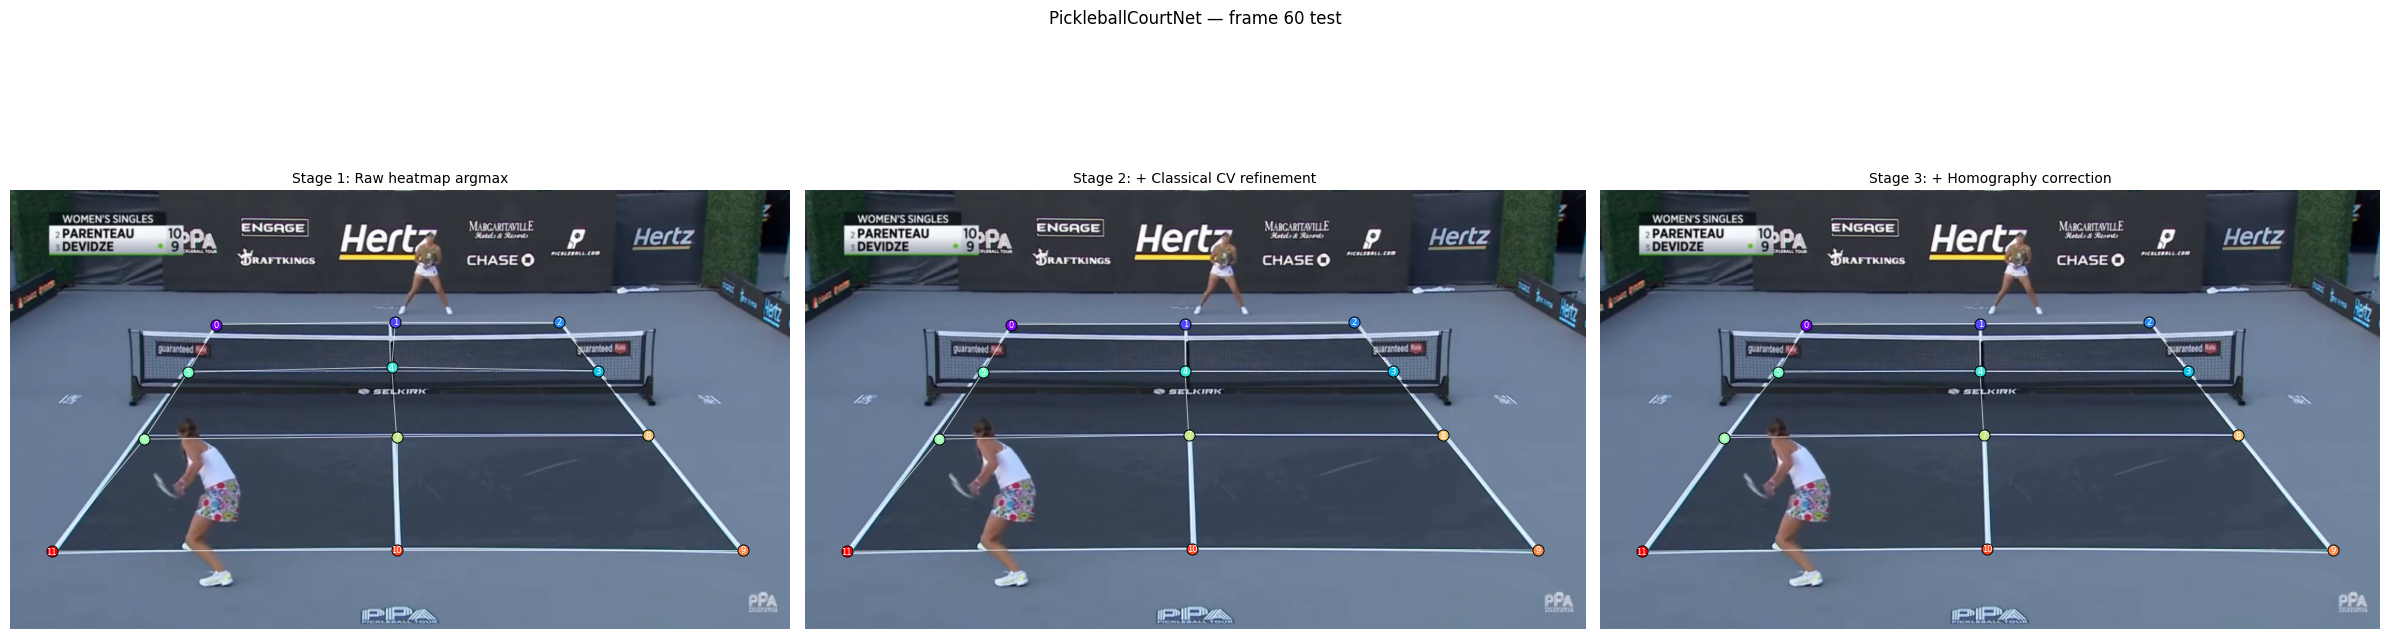

✅ Saved preview: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_frame60.png

👉 If Stage 1 looks reasonable → run Cell 5 for full video
   If Stage 1 is completely wrong → check BEST_PT path in Cell 2


In [ ]:
model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()
print(f"✅ Model loaded: {BEST_PT}")

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ret, frame = cap.read()
cap.release()
assert ret, f"Could not read frame from {VIDEO_PATH}"
print(f"✅ Frame read: {frame.shape[1]}x{frame.shape[0]}")

kps_raw  = predict_keypoints(model, frame, device,
                               apply_refine=False, apply_homography=False)
kps_ref  = predict_keypoints(model, frame, device,
                               apply_refine=True,  apply_homography=False)
kps_full = predict_keypoints(model, frame, device,
                               apply_refine=True,  apply_homography=True)

rgb        = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
colors_plt = plt.cm.rainbow(np.linspace(0,1,12))
fig, axes  = plt.subplots(1, 3, figsize=(24, 8))

for ax, kps, title in [
    (axes[0], kps_raw,  'Stage 1: Raw heatmap argmax'),
    (axes[1], kps_ref,  'Stage 2: + Classical CV refinement'),
    (axes[2], kps_full, 'Stage 3: + Homography correction'),
]:
    ax.imshow(rgb); ax.axis('off'); ax.set_title(title, fontsize=10)
    for (i,j) in SKELETON:
        ax.plot([kps[i][0],kps[j][0]], [kps[i][1],kps[j][1]],
                '-', color='white', lw=0.8, alpha=0.6)
    for k in range(12):
        x, y = kps[k]
        ax.plot(x, y, 'o', color=colors_plt[k], ms=8, mec='black', mew=0.7)
        ax.annotate(str(k), (x,y), fontsize=6, color='white',
                    ha='center', va='center')

plt.suptitle('PickleballCourtNet — frame 60 test', fontsize=12)
plt.tight_layout()
save_img = OUTPUT_PATH.replace('.mp4', '_frame60.png')
plt.savefig(save_img, dpi=120)
plt.show()
print(f"✅ Saved preview: {save_img}")
print(f"\n👉 If Stage 1 looks reasonable → run Cell 5 for full video")
print(f"   If Stage 1 is completely wrong → check BEST_PT path in Cell 2")

In [ ]:
model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()

cap   = cv2.VideoCapture(VIDEO_PATH)
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_v   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out_dir = os.path.dirname(OUTPUT_PATH)
if out_dir: os.makedirs(out_dir, exist_ok=True)

writer = cv2.VideoWriter(OUTPUT_PATH,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          FPS, (W, H_v))

print(f"📹 {W}x{H_v} @ {FPS:.1f}fps — {TOTAL} frames ({TOTAL/FPS:.1f}s)")
print(f"💾 Output → {OUTPUT_PATH}\n")
print(f"   Buffer size : {BUFFER_SIZE} frames")
print(f"   Move thresh : {MOVE_THRESH} px  (jitter below this is ignored)")
print(f"   EMA alpha   : {EMA_ALPHA}  (lower = slower update on real movement)\n")

stabilizer = KPStabilizer(
    buffer_size  = BUFFER_SIZE,
    move_thresh  = MOVE_THRESH,
    ema_alpha    = EMA_ALPHA
)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    frame_idx += 1

    kps = predict_keypoints(model, frame, device,
                             apply_refine=True, apply_homography=True)

    stable_kps = stabilizer.update(kps)

    vis = draw_court(frame, stable_kps)

    cv2.rectangle(vis, (0,0), (W,34), (0,0,0), -1)
    cv2.putText(vis,
                f"Frame {frame_idx}/{TOTAL}  |  PickleballCourtNet (stabilized)",
                (10,22), cv2.FONT_HERSHEY_SIMPLEX, 0.60,
                (0,255,0), 2, cv2.LINE_AA)

    writer.write(vis)

    if frame_idx % 100 == 0:
        pct = frame_idx/TOTAL*100
        print(f"  Frame {frame_idx:>5}/{TOTAL}  ({pct:.1f}%)")

cap.release()
writer.release()
print(f"\n✅ Done — {frame_idx} frames processed")
print(f"   Output: {OUTPUT_PATH}")

📹 1920x1080 @ 30.0fps — 275 frames (9.2s)
💾 Output → /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized.mp4

   Buffer size : 8 frames
   Move thresh : 6 px  (jitter below this is ignored)
   EMA alpha   : 0.05  (lower = slower update on real movement)

  Frame   100/275  (36.4%)
  Frame   200/275  (72.7%)

✅ Done — 275 frames processed
   Output: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized.mp4


# ML6 Post

In [ ]:
!pip install opencv-contrib-python-headless -q

import cv2, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt, os
from collections import deque
from google.colab import drive
drive.mount('/content/drive')

HAS_XIMGPROC = False
try:
    import cv2.ximgproc
    _ = cv2.ximgproc.thinning
    HAS_XIMGPROC = True
    print("✅ ximgproc available")
except Exception:
    print("⚠️  ximgproc fallback mode")

print(f"✅ Ready  |  CUDA:{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 38.6 MB/s eta 0:00:00
Mounted at /content/drive
✅ ximgproc available
✅ Ready  |  CUDA:True
   GPU: NVIDIA L4


In [ ]:
BEST_PT     = '/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt'
VIDEO_PATH  = '/content/drive/MyDrive/In_Out_Pickleball/controversial_call/second.mp4'
OUTPUT_PATH = '/content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_v2.mp4'

BUFFER_SIZE  = 8
MOVE_THRESH  = 6
EMA_ALPHA    = 0.05

CROP_RADIUS         = 40

REFINE_NEAR_RADIUS  = 50
REFINE_MID_RADIUS   = 40
REFINE_FAR_RADIUS   = 32

NEAR_FRAC  = 0.55
FAR_FRAC   = 0.35

HOUGH_THRESHOLD   = 12
HOUGH_MIN_LENGTH  = 8
HOUGH_MAX_GAP     = 8

VOTE_BIN_SIZE  = 2

MIN_ANGLE_DIFF = 15

VERIFY_RADIUS  = 4

print(f"✅ Config loaded")
print(f"   Model  : {BEST_PT}")
print(f"   Video  : {VIDEO_PATH}")
print(f"   Output : {OUTPUT_PATH}")

✅ Config loaded
   Model  : /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt
   Video  : /content/drive/MyDrive/In_Out_Pickleball/controversial_call/second.mp4
   Output : /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_v2.mp4


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1, s=1, bias=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p, bias=bias),
            nn.ReLU(), nn.BatchNorm2d(out_ch)
        )
    def forward(self, x): return self.block(x)

class PickleballCourtNet(nn.Module):
    def __init__(self, out_channels=13):
        super().__init__()
        self.conv1  = ConvBlock(3,   64);  self.conv2  = ConvBlock(64,  64)
        self.pool1  = nn.MaxPool2d(2, 2)
        self.conv3  = ConvBlock(64,  128); self.conv4  = ConvBlock(128, 128)
        self.pool2  = nn.MaxPool2d(2, 2)
        self.conv5  = ConvBlock(128, 256); self.conv6  = ConvBlock(256, 256)
        self.conv7  = ConvBlock(256, 256); self.pool3  = nn.MaxPool2d(2, 2)
        self.conv8  = ConvBlock(256, 512); self.conv9  = ConvBlock(512, 512)
        self.conv10 = ConvBlock(512, 512)
        self.ups1   = nn.Upsample(scale_factor=2)
        self.conv11 = ConvBlock(512, 256); self.conv12 = ConvBlock(256, 256)
        self.conv13 = ConvBlock(256, 256)
        self.ups2   = nn.Upsample(scale_factor=2)
        self.conv14 = ConvBlock(256, 128); self.conv15 = ConvBlock(128, 128)
        self.ups3   = nn.Upsample(scale_factor=2)
        self.conv16 = ConvBlock(128, 64);  self.conv17 = ConvBlock(64,  64)
        self.conv18 = ConvBlock(64,  out_channels)

    def forward(self, x):
        x = self.conv1(x);  x = self.conv2(x);  x = self.pool1(x)
        x = self.conv3(x);  x = self.conv4(x);  x = self.pool2(x)
        x = self.conv5(x);  x = self.conv6(x);  x = self.conv7(x)
        x = self.pool3(x)
        x = self.conv8(x);  x = self.conv9(x);  x = self.conv10(x)
        x = self.ups1(x);   x = self.conv11(x); x = self.conv12(x); x = self.conv13(x)
        x = self.ups2(x);   x = self.conv14(x); x = self.conv15(x)
        x = self.ups3(x);   x = self.conv16(x); x = self.conv17(x); x = self.conv18(x)
        return x

SKELETON = [
    (0,1),(1,2),(3,4),(4,5),(6,7),(7,8),(9,10),(10,11),
    (0,5),(2,3),(5,6),(3,8),(6,11),(8,9),(1,4),(4,7),(7,10),
]
REF_KPS = np.array([
    [  0,1372],[305,1372],[610,1372],
    [610, 915],[305, 915],[  0, 915],
    [  0, 457],[305, 457],[610, 457],
    [610,   0],[305,   0],[  0,   0],
], dtype=np.float32)
CONFIGS = [
    [0,2,9,11],[0,2,6,8],[0,2,3,5],[6,8,9,11],
    [0,5,6,11],[2,3,8,9],[1,7,10,4],[0,1,9,10],
    [1,2,10,9],[0,2,1,10],[3,5,6,8],[0,11,2,9],
]

def skeletonize(binary):
    if HAS_XIMGPROC:
        try:
            b = (binary > 0).astype(np.uint8) * 255
            return cv2.ximgproc.thinning(b, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
        except Exception:
            pass
    binary_u8 = (binary > 0).astype(np.uint8) * 255
    skeleton  = np.zeros_like(binary_u8)
    element   = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    temp      = binary_u8.copy()
    while True:
        eroded   = cv2.erode(temp, element)
        opened   = cv2.dilate(eroded, element)
        skeleton = cv2.bitwise_or(skeleton, cv2.subtract(temp, opened))
        temp     = eroded.copy()
        if cv2.countNonZero(temp) == 0:
            break
    return skeleton

def _dominant_color_removal(crop_bgr, n_colors=4):
    """
    ML6 step 1: Remove dominant (background) colors from the crop.

    Use k-means to find the N most common colors. The most dominant color
    is usually the court surface (dark navy/blue-grey). Remove those pixels
    so white court lines stand out more clearly.

    Returns a mask where True = pixel is NOT the dominant background color.
    """
    h, w = crop_bgr.shape[:2]
    pixels = crop_bgr.reshape(-1, 3).astype(np.float32)

    if len(pixels) < n_colors * 4:
        return np.ones((h, w), dtype=bool)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(
        pixels, n_colors, None, criteria,
        attempts=3, flags=cv2.KMEANS_RANDOM_CENTERS
    )

    labels = labels.flatten()
    centers = centers.astype(np.uint8)

    counts = np.bincount(labels, minlength=n_colors)
    dominant_label = np.argmax(counts)

    dominant_color = centers[dominant_label].astype(float)

    keep_mask = np.ones(len(pixels), dtype=bool)
    for i, center in enumerate(centers):
        brightness = float(center.mean())
        if brightness < 100 and counts[i] > 0.20 * len(pixels):
            keep_mask[labels == i] = False
        elif counts[i] > 0.50 * len(pixels) and brightness < 200:
            keep_mask[labels == i] = False

    return keep_mask.reshape(h, w)

def _get_crop_radius(kp_y, frame_h):
    """
    ML6 improvement: Adaptive crop size based on keypoint distance from camera.

    Far keypoints (top of image) → lines appear thinner → smaller crop.
    Near keypoints (bottom of image) → lines appear thicker → larger crop.
    """
    frac = kp_y / max(frame_h, 1)
    if frac > NEAR_FRAC:
        return REFINE_NEAR_RADIUS
    elif frac < FAR_FRAC:
        return REFINE_FAR_RADIUS
    else:
        t = (frac - FAR_FRAC) / (NEAR_FRAC - FAR_FRAC)
        return int(REFINE_FAR_RADIUS + t * (REFINE_NEAR_RADIUS - REFINE_FAR_RADIUS))

def _should_dilate(kp_y, frame_h):
    """
    ML6 step 2: Thicken lines for far-away keypoints.
    Returns dilation kernel size (0 = no dilation).
    """
    frac = kp_y / max(frame_h, 1)
    if frac < FAR_FRAC:
        return 3
    elif frac < 0.45:
        return 2
    else:
        return 0

def _find_all_intersections(lines):
    """
    Find ALL pairwise intersections between detected line segments.

    Returns list of (x, y) intersection candidates.
    Only keeps pairs where the angle between lines > MIN_ANGLE_DIFF degrees.
    This is more robust than the fixed H/V categorization because it works
    for any orientation of lines in perspective view.
    """
    if lines is None or len(lines) < 2:
        return []

    segs = []
    for ln in lines:
        x1, y1, x2, y2 = ln[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
        segs.append((x1, y1, x2, y2, angle))

    intersections = []
    for i in range(len(segs)):
        for j in range(i + 1, len(segs)):
            x1, y1, x2, y2, a1 = segs[i]
            x3, y3, x4, y4, a2 = segs[j]

            angle_diff = abs(a1 - a2)
            angle_diff = min(angle_diff, 180 - angle_diff)
            if angle_diff < MIN_ANGLE_DIFF:
                continue

            denom = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
            if abs(denom) < 1e-6:
                continue

            t = ((x1-x3)*(y3-y4) - (y1-y3)*(x3-x4)) / denom
            ix = x1 + t*(x2 - x1)
            iy = y1 + t*(y2 - y1)

            intersections.append((float(ix), float(iy)))

    return intersections

def _vote_best_intersection(intersections, crop_w, crop_h, bin_size=VOTE_BIN_SIZE):
    """
    ML6 improvement: Use voting to find the intersection with most support.

    Instead of just taking the intersection closest to the crop center,
    we find the point that has the most other intersections nearby.
    This is the "Hough voting in intersection space" approach.

    Returns (best_x, best_y) or None.
    """
    margin = 10
    valid = [(x, y) for x, y in intersections
             if -margin <= x <= crop_w + margin
             and -margin <= y <= crop_h + margin]

    if not valid:
        return None
    if len(valid) == 1:
        return valid[0]

    xs = np.array([p[0] for p in valid])
    ys = np.array([p[1] for p in valid])

    x_min = max(0, xs.min() - bin_size)
    y_min = max(0, ys.min() - bin_size)

    x_bins = ((xs - x_min) / bin_size).astype(int)
    y_bins = ((ys - y_min) / bin_size).astype(int)

    if x_bins.max() == 0 and y_bins.max() == 0:
        return valid[0]

    grid_w = x_bins.max() + 1
    grid_h = y_bins.max() + 1
    acc    = np.zeros((grid_h, grid_w), dtype=int)
    for xb, yb in zip(x_bins, y_bins):
        acc[yb, xb] += 1

    if grid_w > 2 and grid_h > 2:
        kernel = np.ones((3, 3), dtype=np.float32) / 9.0
        acc_smooth = cv2.filter2D(acc.astype(np.float32), -1, kernel)
    else:
        acc_smooth = acc.astype(np.float32)

    best_yb, best_xb = np.unravel_index(acc_smooth.argmax(), acc_smooth.shape)
    best_x = best_xb * bin_size + x_min
    best_y = best_yb * bin_size + y_min

    refined_xs, refined_ys = [], []
    for x, y in valid:
        if (abs(x - best_x) <= bin_size * 2 and
                abs(y - best_y) <= bin_size * 2):
            refined_xs.append(x)
            refined_ys.append(y)

    if refined_xs:
        return (float(np.mean(refined_xs)), float(np.mean(refined_ys)))
    return (float(best_x), float(best_y))

def _verify_on_line_pixel(ix, iy, white_mask, radius=VERIFY_RADIUS):
    """
    ML6 verification step: Only accept the intersection if it falls on
    (or very near) an actual white pixel in the line mask.

    Returns True if the intersection has white pixel support.
    """
    h, w = white_mask.shape
    xi, yi = int(round(ix)), int(round(iy))
    y1 = max(0, yi - radius)
    y2 = min(h, yi + radius + 1)
    x1 = max(0, xi - radius)
    x2 = min(w, xi + radius + 1)
    roi = white_mask[y1:y2, x1:x2]
    return bool(np.any(roi > 0))

def refine_kps_cv(frame_bgr, kps, crop_radius=40):
    """Original refine_kps_cv — unchanged from your existing code."""
    H_f, W_f     = frame_bgr.shape[:2]
    refined_kps  = kps.copy().astype(float)
    refined_mask = np.zeros(len(kps), dtype=bool)
    for k in range(len(kps)):
        px, py = kps[k]
        if px < 0 or py < 0: continue
        cx = int(round(px)); cy = int(round(py))
        cx1 = max(0, cx-crop_radius);     cy1 = max(0, cy-crop_radius)
        cx2 = min(W_f-1, cx+crop_radius); cy2 = min(H_f-1, cy+crop_radius)
        if (cx2-cx1) < 10 or (cy2-cy1) < 10: continue
        crop       = frame_bgr[cy1:cy2, cx1:cx2]
        hsv        = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        white_mask = cv2.inRange(hsv, np.array([0,0,160]),  np.array([180,60,255]))
        green_mask = cv2.inRange(hsv, np.array([30,30,30]), np.array([90,255,255]))
        white_mask[green_mask > 0] = 0
        skeleton   = skeletonize(white_mask)
        lines      = cv2.HoughLinesP(skeleton, 1, np.pi/180,
                                      threshold=15, minLineLength=10, maxLineGap=10)
        if lines is None or len(lines) < 2: continue
        h_lines, v_lines = [], []
        for ln in lines:
            lx1,ly1,lx2,ly2 = ln[0]
            angle = abs(np.degrees(np.arctan2(ly2-ly1, lx2-lx1)))
            if angle < 30 or angle > 150: h_lines.append(ln[0])
            elif 60 < angle < 120:        v_lines.append(ln[0])
        if not h_lines or not v_lines: continue
        ccx, ccy    = crop.shape[1]//2, crop.shape[0]//2
        best_pt, best_d = None, float('inf')
        for hl in h_lines:
            for vl in v_lines:
                hl_x1,hl_y1,hl_x2,hl_y2 = hl
                vl_x1,vl_y1,vl_x2,vl_y2 = vl
                denom = ((hl_x1-hl_x2)*(vl_y1-vl_y2) -
                         (hl_y1-hl_y2)*(vl_x1-vl_x2))
                if abs(denom) < 1e-6: continue
                t  = ((hl_x1-vl_x1)*(vl_y1-vl_y2) -
                      (hl_y1-vl_y1)*(vl_x1-vl_x2)) / denom
                ix = hl_x1+t*(hl_x2-hl_x1); iy = hl_y1+t*(hl_y2-hl_y1)
                if not (0<=ix<crop.shape[1] and 0<=iy<crop.shape[0]): continue
                xi, yi = int(round(ix)), int(round(iy))
                roi = white_mask[max(0,yi-3):yi+4, max(0,xi-3):xi+4]
                if not np.any(roi > 0): continue
                d = np.hypot(ix-ccx, iy-ccy)
                if d < best_d: best_d, best_pt = d, (ix, iy)
        if best_pt is not None:
            rx = cx1+best_pt[0]; ry = cy1+best_pt[1]
            if np.hypot(rx-cx, ry-cy) < crop_radius*0.9:
                refined_kps[k]  = [rx, ry]
                refined_mask[k] = True
    return refined_kps, refined_mask

def refine_kps_cv_v2(frame_bgr, kps):
    """
    ML6-inspired post-processing for court keypoint refinement.

    Improvements over the original refine_kps_cv():
    1. Dominant color removal  — strips court surface color before line detection
    2. Adaptive crop size      — larger crops near camera, smaller for far keypoints
    3. Adaptive line dilation  — thickens thin far-away lines before skeletonizing
    4. All-pairs intersection  — doesn't require strict H/V line categorization
    5. Voting-based best point — most-voted intersection, not just closest-to-center
    6. White-pixel verification — only accept if intersection lands on a line pixel

    Parameters
    ----------
    frame_bgr : full video frame (H, W, 3) BGR
    kps       : (12, 2) float32 predicted keypoints in image pixel coords

    Returns
    -------
    refined_kps  : (12, 2) float32 — improved keypoint positions
    refined_mask : (12,) bool      — True where refinement was accepted
    """
    H_f, W_f     = frame_bgr.shape[:2]
    refined_kps  = kps.copy().astype(float)
    refined_mask = np.zeros(len(kps), dtype=bool)

    for k in range(len(kps)):
        px, py = kps[k]
        if px < 0 or py < 0:
            continue

        cx = int(round(px))
        cy = int(round(py))

        crop_radius = _get_crop_radius(cy, H_f)
        cx1 = max(0, cx - crop_radius)
        cy1 = max(0, cy - crop_radius)
        cx2 = min(W_f - 1, cx + crop_radius)
        cy2 = min(H_f - 1, cy + crop_radius)
        if (cx2 - cx1) < 10 or (cy2 - cy1) < 10:
            continue

        crop = frame_bgr[cy1:cy2, cx1:cx2]
        crop_h, crop_w = crop.shape[:2]

        keep_mask_dc = _dominant_color_removal(crop, n_colors=4)

        hsv        = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        white_mask = cv2.inRange(hsv, np.array([0, 0, 150]),
                                      np.array([180, 55, 255]))
        green_mask = cv2.inRange(hsv, np.array([30, 30, 30]),
                                      np.array([90, 255, 255]))
        white_mask[green_mask > 0] = 0

        white_mask[~keep_mask_dc] = 0

        gray       = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        bright_mask = (gray > 160).astype(np.uint8) * 255
        bright_mask[green_mask > 0] = 0
        bright_mask[~keep_mask_dc] = 0

        line_mask = cv2.bitwise_or(white_mask, bright_mask)

        if cv2.countNonZero(line_mask) < 5:
            line_mask = white_mask.copy()
            if cv2.countNonZero(line_mask) < 5:
                continue

        dil_size = _should_dilate(cy, H_f)
        if dil_size > 0:
            kernel    = cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE, (dil_size, dil_size)
            )
            line_mask = cv2.dilate(line_mask, kernel, iterations=1)

        skeleton = skeletonize(line_mask)

        lines = cv2.HoughLinesP(
            skeleton, rho=1, theta=np.pi / 180,
            threshold=HOUGH_THRESHOLD,
            minLineLength=HOUGH_MIN_LENGTH,
            maxLineGap=HOUGH_MAX_GAP
        )
        if lines is None or len(lines) < 2:
            continue

        all_intersections = _find_all_intersections(lines)
        if not all_intersections:
            continue

        best = _vote_best_intersection(
            all_intersections, crop_w, crop_h, bin_size=VOTE_BIN_SIZE
        )
        if best is None:
            continue

        ix_crop, iy_crop = best

        if not _verify_on_line_pixel(ix_crop, iy_crop, line_mask,
                                      radius=VERIFY_RADIUS):
            continue

        rx = cx1 + ix_crop
        ry = cy1 + iy_crop

        displacement = np.hypot(rx - cx, ry - cy)
        if displacement > crop_radius * 0.85:
            continue

        refined_kps[k]  = [rx, ry]
        refined_mask[k] = True

    return refined_kps, refined_mask

def get_best_homography(kps):
    visible = {k: kps[k] for k in range(12)
               if kps[k][0] >= 0 and kps[k][1] >= 0}
    if len(visible) < 4:
        return None
    best_H, best_err = None, float('inf')
    for conf in CONFIGS:
        if not all(c in visible for c in conf):
            continue
        src  = np.float32([REF_KPS[c] for c in conf])
        dst  = np.float32([kps[c]     for c in conf])
        H, _ = cv2.findHomography(src, dst, method=0)
        if H is None:
            continue
        proj = cv2.perspectiveTransform(REF_KPS.reshape(-1, 1, 2), H).reshape(-1, 2)
        errs = [np.hypot(visible[k][0] - proj[k][0], visible[k][1] - proj[k][1])
                for k in visible if k not in conf]
        if not errs:
            continue
        mean_err = np.mean(errs)
        if mean_err < best_err:
            best_err, best_H = mean_err, H
    return best_H

def apply_homography_correction(kps, H):
    if H is None:
        return kps.copy()
    proj      = cv2.perspectiveTransform(REF_KPS.reshape(-1, 1, 2), H).reshape(-1, 2)
    corrected = kps.copy().astype(float)
    for k in range(12):
        if kps[k][0] < 0 or kps[k][1] < 0:
            corrected[k] = proj[k]
        else:
            dist = np.hypot(kps[k][0] - proj[k][0], kps[k][1] - proj[k][1])
            if dist > 15:
                corrected[k] = proj[k]
    return corrected

def predict_keypoints(model, frame_bgr, device,
                       apply_refine=True, apply_homography=True):
    """
    Full 4-stage pipeline:
      Stage 1 — Raw heatmap argmax
      Stage 2 — Classical CV refinement (original refine_kps_cv)
      Stage 3 — Homography correction
      Stage 4 — ML6 post-processing refinement (refine_kps_cv_v2)
                 Runs AFTER homography so it starts from already-good
                 positions and sharpens each point onto the exact
                 line intersection.
    """
    H_orig, W_orig = frame_bgr.shape[:2]
    MODEL_H, MODEL_W = 360, 640
    img = cv2.resize(frame_bgr, (MODEL_W, MODEL_H))
    inp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    inp = torch.FloatTensor(inp.transpose(2, 0, 1)).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        hm = model(inp)
    hm_np = hm[0, :12].cpu().numpy()
    kps   = np.zeros((12, 2), dtype=np.float32)
    for k in range(12):
        flat_idx = hm_np[k].argmax()
        kps[k]   = [int(flat_idx % MODEL_W) * W_orig / MODEL_W,
                    int(flat_idx // MODEL_W) * H_orig / MODEL_H]

    if apply_refine:
        kps, _ = refine_kps_cv(frame_bgr, kps, crop_radius=CROP_RADIUS)

    if apply_homography:
        H_mat = get_best_homography(kps)
        kps   = apply_homography_correction(kps, H_mat)

    if apply_refine:
        kps, _ = refine_kps_cv_v2(frame_bgr, kps)

    return kps

class KPStabilizer:
    def __init__(self, buffer_size=8, move_thresh=6, ema_alpha=0.05):
        self.buffer      = deque(maxlen=buffer_size)
        self.move_thresh = move_thresh
        self.ema_alpha   = ema_alpha
        self.locked      = None

    def update(self, kps):
        self.buffer.append(kps.copy())
        if len(self.buffer) >= 3:
            stacked    = np.stack(list(self.buffer), axis=0)
            median_kps = np.median(stacked, axis=0)
        else:
            median_kps = kps.copy()
        if self.locked is None:
            self.locked = median_kps.copy().astype(float)
        else:
            for k in range(12):
                dist = np.hypot(
                    median_kps[k][0] - self.locked[k][0],
                    median_kps[k][1] - self.locked[k][1]
                )
                if dist > self.move_thresh:
                    self.locked[k][0] = (self.ema_alpha * median_kps[k][0] +
                                         (1 - self.ema_alpha) * self.locked[k][0])
                    self.locked[k][1] = (self.ema_alpha * median_kps[k][1] +
                                         (1 - self.ema_alpha) * self.locked[k][1])
        return self.locked.copy()

def draw_court(frame, kps):
    vis = frame.copy()
    for (i, j) in SKELETON:
        cv2.line(vis,
                 (int(kps[i][0]), int(kps[i][1])),
                 (int(kps[j][0]), int(kps[j][1])),
                 (255, 255, 255), 1, cv2.LINE_AA)
    for k in range(12):
        x, y = int(kps[k][0]), int(kps[k][1])
        cv2.circle(vis, (x, y), 7, (0, 0, 255), -1, cv2.LINE_AA)
        cv2.circle(vis, (x, y), 7, (0, 0,   0),  1, cv2.LINE_AA)
        cv2.putText(vis, str(k), (x - 4, y + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.30,
                    (255, 255, 255), 1, cv2.LINE_AA)
    return vis

print(f"✅ All functions loaded  |  Device: {device}")
print(f"   Using IMPROVED refine_kps_cv_v2 (ML6 post-processing)")

✅ All functions loaded  |  Device: cuda
   Using IMPROVED refine_kps_cv_v2 (ML6 post-processing)


✅ Model loaded: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/best.pt
✅ Frame read: 1920x1080


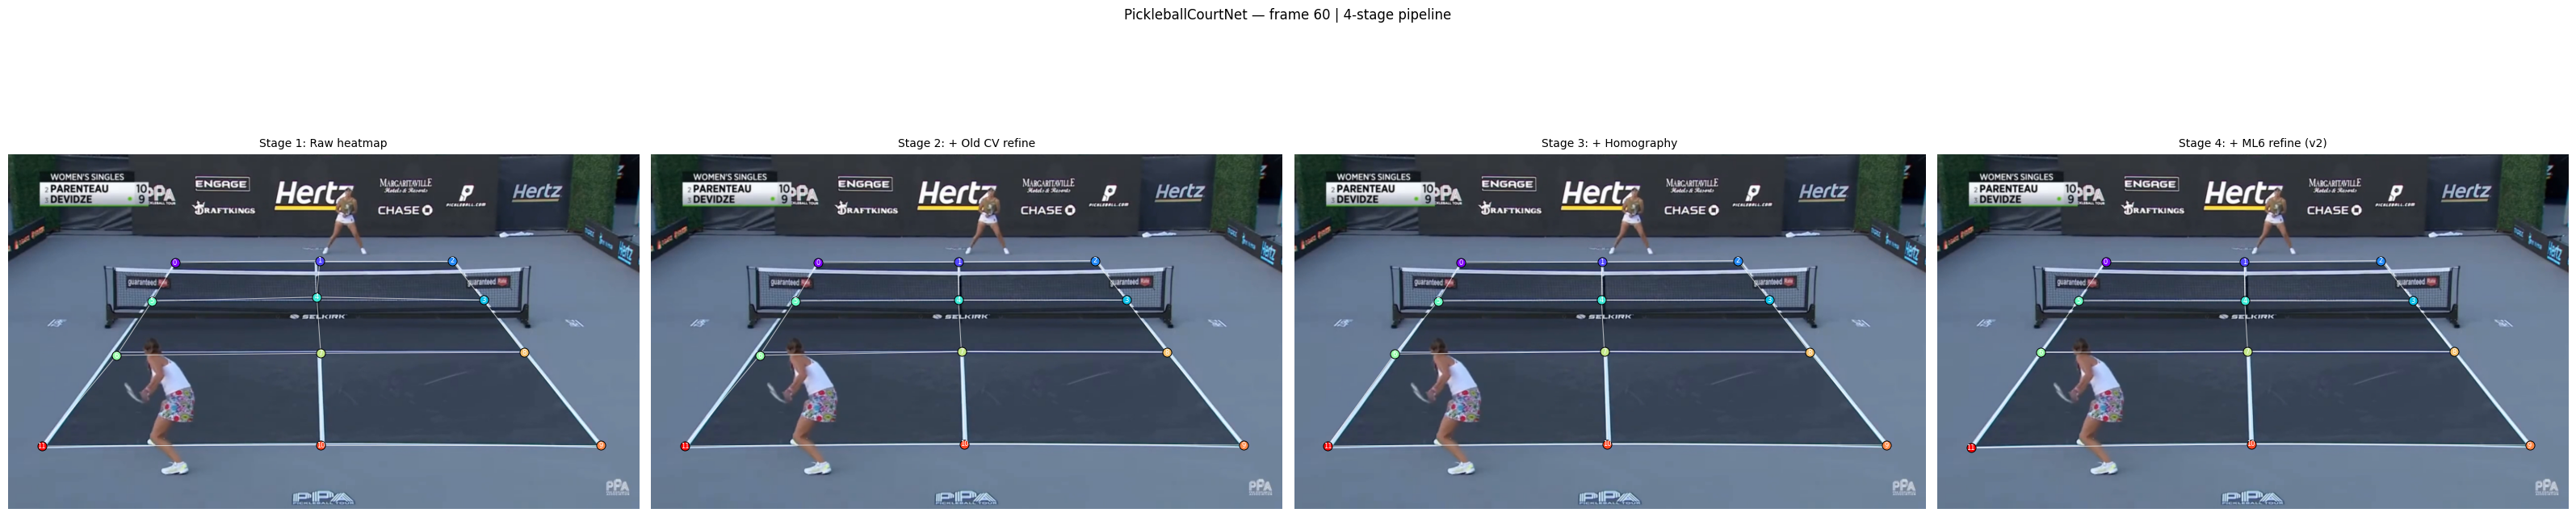

✅ Saved preview: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_v2_frame60_v2.png

Per-keypoint displacement: Stage 3 (homography) → Stage 4 (ML6 refine)
   kp       Δx       Δy     dist    refined?
  ---------------------------------------------
  kp 0     +5.7     -3.0      6.5       ✓ YES
  kp 1     -1.1     +0.5      1.2       ✓ YES
  kp 2     +0.0     +0.0      0.0        — no
  kp 3     +2.2     +1.0      2.4       ✓ YES
  kp 4     +1.0     +1.0      1.4       ✓ YES
  kp 5     -8.5     -2.0      8.8       ✓ YES
  kp 6    +10.8     -5.5     12.1       ✓ YES
  kp 7     +1.1     +0.2      1.1       ✓ YES
  kp 8     +3.2     -2.0      3.8       ✓ YES
  kp 9     +0.0     +0.0      0.0        — no
  kp10     +2.3     -0.3      2.3       ✓ YES
  kp11     +0.8     +5.5      5.5       ✓ YES


In [ ]:
model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()
print(f"✅ Model loaded: {BEST_PT}")

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ret, frame = cap.read()
cap.release()
assert ret, f"Could not read frame from {VIDEO_PATH}"
print(f"✅ Frame read: {frame.shape[1]}x{frame.shape[0]}")

kps_s1 = predict_keypoints(model, frame, device, apply_refine=False, apply_homography=False)

kps_s2 = kps_s1.copy().astype(float)
kps_s2, _ = refine_kps_cv(frame, kps_s2, crop_radius=CROP_RADIUS)

kps_s3 = kps_s2.copy()
H_mat = get_best_homography(kps_s3)
kps_s3 = apply_homography_correction(kps_s3, H_mat)

kps_s4 = kps_s3.copy().astype(float)
kps_s4, refined_mask = refine_kps_cv_v2(frame, kps_s4)

rgb        = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
colors_plt = plt.cm.rainbow(np.linspace(0, 1, 12))
fig, axes  = plt.subplots(1, 4, figsize=(32, 8))

for ax, kps, title in [
    (axes[0], kps_s1, 'Stage 1: Raw heatmap'),
    (axes[1], kps_s2, 'Stage 2: + Old CV refine'),
    (axes[2], kps_s3, 'Stage 3: + Homography'),
    (axes[3], kps_s4, 'Stage 4: + ML6 refine (v2)'),
]:
    ax.imshow(rgb); ax.axis('off'); ax.set_title(title, fontsize=10)
    for (i, j) in SKELETON:
        ax.plot([kps[i][0], kps[j][0]], [kps[i][1], kps[j][1]],
                '-', color='white', lw=0.8, alpha=0.6)
    for k in range(12):
        x, y = kps[k]
        ax.plot(x, y, 'o', color=colors_plt[k], ms=8, mec='black', mew=0.7)
        ax.annotate(str(k), (x, y), fontsize=6, color='white',
                    ha='center', va='center')

plt.suptitle('PickleballCourtNet — frame 60 | 4-stage pipeline', fontsize=12)
plt.tight_layout()
save_img = OUTPUT_PATH.replace('.mp4', '_frame60_v2.png')
plt.savefig(save_img, dpi=150)
plt.show()
print(f"✅ Saved preview: {save_img}")

print(f"\nPer-keypoint displacement: Stage 3 (homography) → Stage 4 (ML6 refine)")
print(f"  {'kp':>3}  {'Δx':>7}  {'Δy':>7}  {'dist':>7}  {'refined?':>10}")
print(f"  {'-'*45}")
for k in range(12):
    dx = kps_s4[k][0] - kps_s3[k][0]
    dy = kps_s4[k][1] - kps_s3[k][1]
    d  = np.hypot(dx, dy)
    print(f"  kp{k:>2}  {dx:>+7.1f}  {dy:>+7.1f}  {d:>7.1f}  "
          f"{'✓ YES' if refined_mask[k] else '— no':>10}")

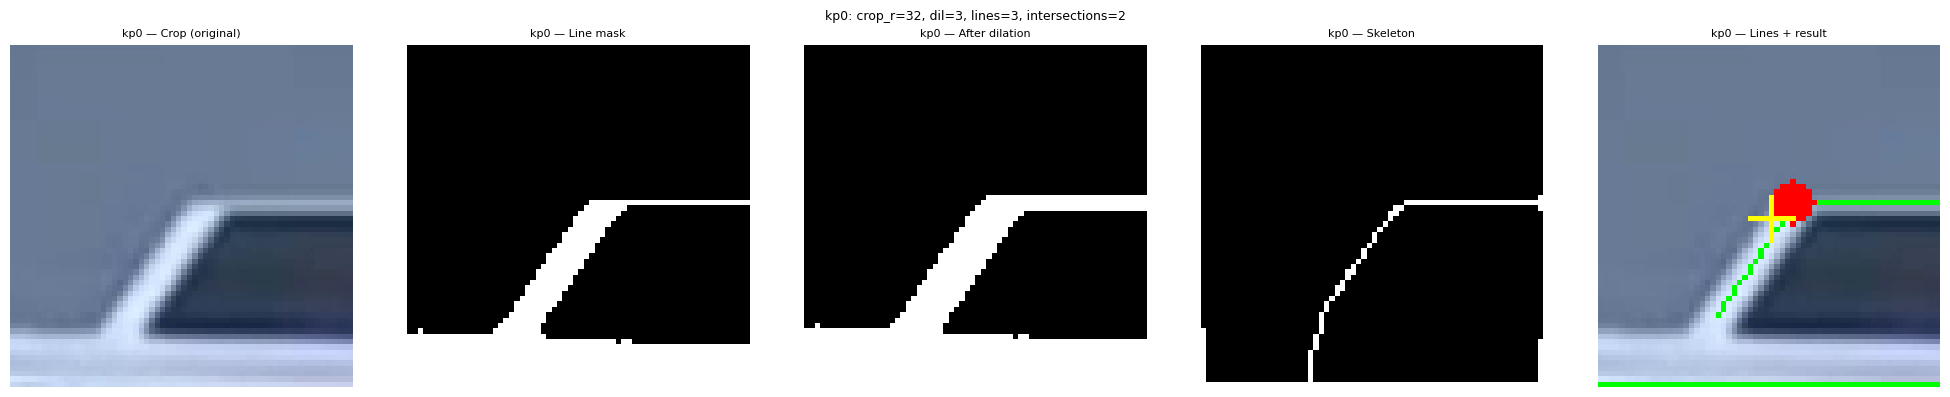

kp0: original=(507.0,330.0)  best_intersection=(36.7, 29.0)  crop_radius=32  dil=3


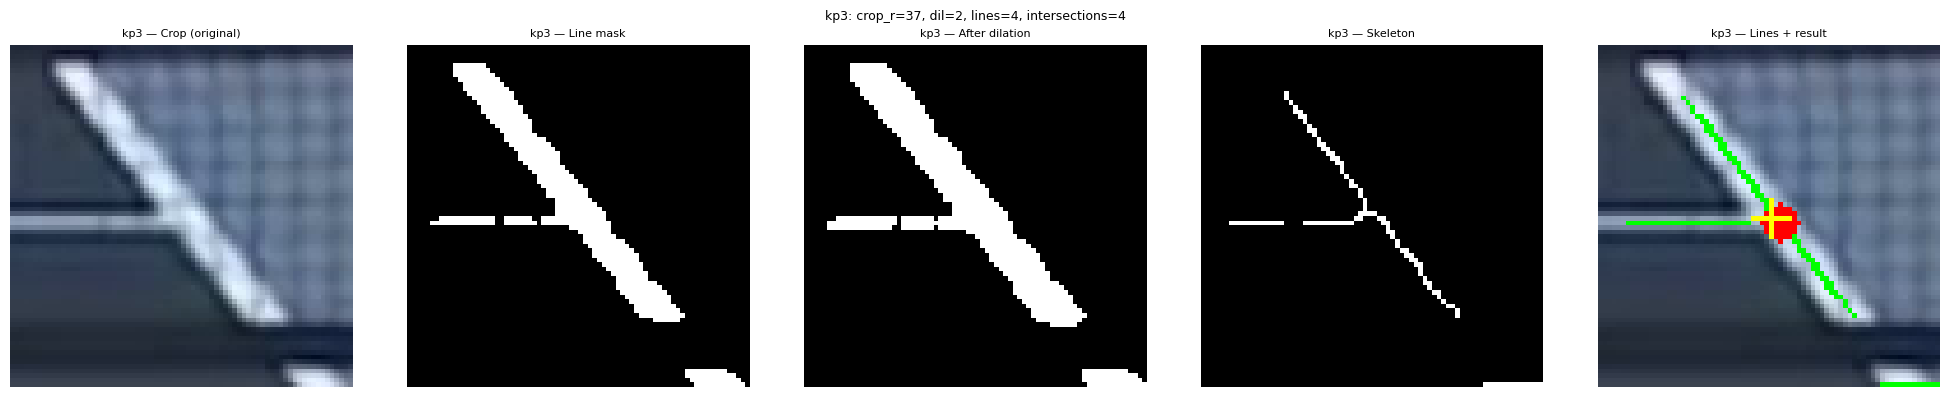

kp3: original=(1446.0,444.0)  best_intersection=(39.18604651162791, 38.0)  crop_radius=37  dil=2


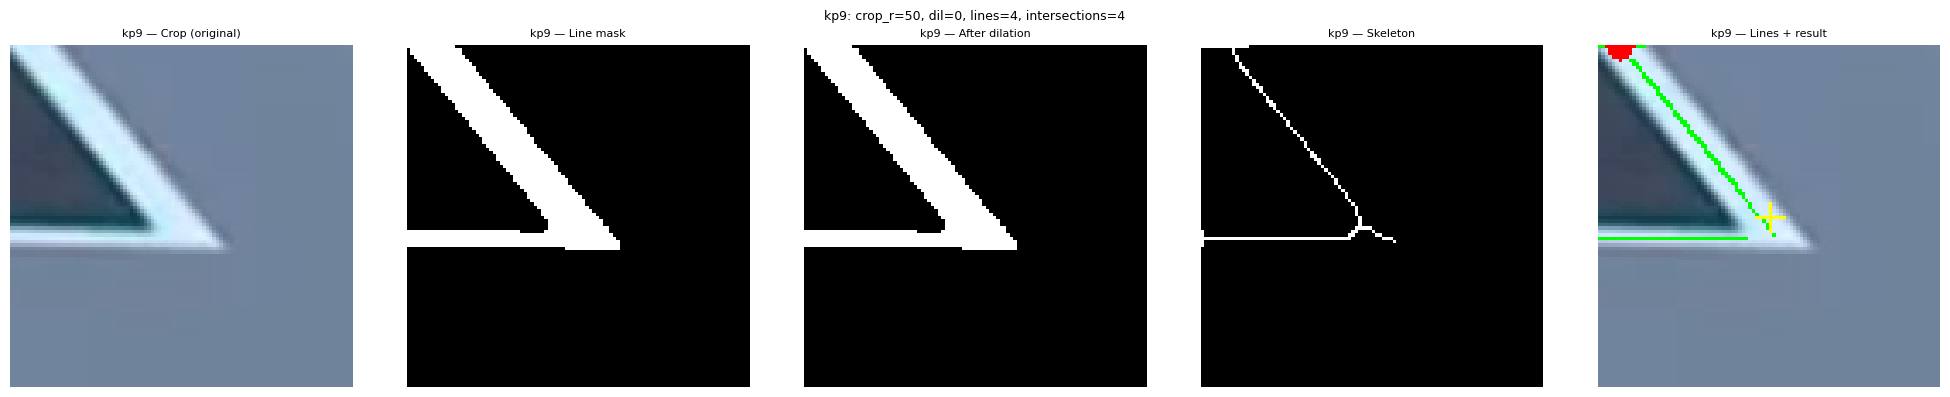

kp9: original=(1803.0,885.0)  best_intersection=(6.3589743589743595, 0.0)  crop_radius=50  dil=0


In [ ]:
def debug_crop_refinement(frame_bgr, kp_idx, kps):
    """
    Visualize the intermediate steps of refine_kps_cv_v2 for one keypoint.
    Useful for tuning HOUGH_THRESHOLD, REFINE_*_RADIUS, etc.
    """
    H_f, W_f = frame_bgr.shape[:2]
    px, py   = kps[kp_idx]
    cx, cy   = int(round(px)), int(round(py))

    crop_radius = _get_crop_radius(cy, H_f)
    cx1 = max(0, cx - crop_radius); cy1 = max(0, cy - crop_radius)
    cx2 = min(W_f-1, cx+crop_radius); cy2 = min(H_f-1, cy+crop_radius)
    crop = frame_bgr[cy1:cy2, cx1:cx2]

    keep_dc  = _dominant_color_removal(crop, n_colors=4)
    hsv      = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    w_mask   = cv2.inRange(hsv, np.array([0,0,150]),  np.array([180,55,255]))
    g_mask   = cv2.inRange(hsv, np.array([30,30,30]), np.array([90,255,255]))
    w_mask[g_mask > 0] = 0
    w_mask[~keep_dc]   = 0
    gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    b_mask   = (gray > 160).astype(np.uint8) * 255
    b_mask[g_mask > 0] = 0; b_mask[~keep_dc] = 0
    line_mask = cv2.bitwise_or(w_mask, b_mask)
    if cv2.countNonZero(line_mask) < 5:
        line_mask = w_mask.copy()

    dil = _should_dilate(cy, H_f)
    if dil > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dil, dil))
        line_mask_dil = cv2.dilate(line_mask, kernel)
    else:
        line_mask_dil = line_mask.copy()

    skeleton = skeletonize(line_mask_dil)
    lines    = cv2.HoughLinesP(skeleton, 1, np.pi/180,
                                threshold=HOUGH_THRESHOLD,
                                minLineLength=HOUGH_MIN_LENGTH,
                                maxLineGap=HOUGH_MAX_GAP)
    all_ints = _find_all_intersections(lines) if lines is not None else []
    best     = _vote_best_intersection(all_ints, crop.shape[1], crop.shape[0])

    crop_lines = cv2.cvtColor(crop.copy(), cv2.COLOR_BGR2RGB)
    if lines is not None:
        for ln in lines:
            x1,y1,x2,y2 = ln[0]
            cv2.line(crop_lines, (x1,y1), (x2,y2), (0,255,0), 1)
    if best:
        bx, by = int(best[0]), int(best[1])
        cv2.circle(crop_lines, (bx, by), 4, (255,0,0), -1)
    ox = cx - cx1; oy = cy - cy1
    cv2.drawMarker(crop_lines, (ox, oy), (255,255,0), cv2.MARKER_CROSS, 8, 1)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    titles = ['Crop (original)', 'Line mask', 'After dilation',
              'Skeleton', 'Lines + result']
    imgs   = [
        cv2.cvtColor(crop, cv2.COLOR_BGR2RGB),
        line_mask,
        line_mask_dil,
        skeleton,
        crop_lines
    ]
    for ax, img, t in zip(axes, imgs, titles):
        ax.imshow(img, cmap='gray' if img.ndim==2 else None)
        ax.set_title(f"kp{kp_idx} — {t}", fontsize=8)
        ax.axis('off')
    plt.suptitle(f"kp{kp_idx}: crop_r={crop_radius}, dil={dil}, "
                 f"lines={len(lines) if lines is not None else 0}, "
                 f"intersections={len(all_ints)}", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"kp{kp_idx}: original=({px:.1f},{py:.1f})  "
          f"best_intersection={best}  "
          f"crop_radius={crop_radius}  dil={dil}")

for kp_test in [0, 3, 9]:
    debug_crop_refinement(frame, kp_test, kps_s3)

In [ ]:
model = PickleballCourtNet(out_channels=13).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()

cap   = cv2.VideoCapture(VIDEO_PATH)
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_v   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out_dir = os.path.dirname(OUTPUT_PATH)
if out_dir: os.makedirs(out_dir, exist_ok=True)

writer = cv2.VideoWriter(OUTPUT_PATH,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          FPS, (W, H_v))

print(f"📹 {W}x{H_v} @ {FPS:.1f}fps — {TOTAL} frames ({TOTAL/FPS:.1f}s)")
print(f"💾 Output → {OUTPUT_PATH}\n")
print(f"   Using refine_kps_cv_v2  (ML6 post-processing)")
print(f"   Buffer size : {BUFFER_SIZE}")
print(f"   Move thresh : {MOVE_THRESH} px")
print(f"   EMA alpha   : {EMA_ALPHA}\n")

stabilizer = KPStabilizer(buffer_size=BUFFER_SIZE,
                           move_thresh=MOVE_THRESH,
                           ema_alpha=EMA_ALPHA)
frame_idx = 0

import time
t_start = time.time()

while True:
    ret, frame = cap.read()
    if not ret: break
    frame_idx += 1

    kps        = predict_keypoints(model, frame, device,
                                    apply_refine=True, apply_homography=True)
    stable_kps = stabilizer.update(kps)
    vis        = draw_court(frame, stable_kps)

    cv2.rectangle(vis, (0, 0), (W, 34), (0, 0, 0), -1)
    cv2.putText(vis,
                f"Frame {frame_idx}/{TOTAL}  |  PickleballCourtNet v2 (ML6 post-proc)",
                (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.60,
                (0, 255, 0), 2, cv2.LINE_AA)

    writer.write(vis)

    if frame_idx % 50 == 0:
        elapsed = time.time() - t_start
        fps_proc = frame_idx / elapsed
        eta      = (TOTAL - frame_idx) / fps_proc if fps_proc > 0 else 0
        print(f"  Frame {frame_idx:>5}/{TOTAL}  "
              f"({frame_idx/TOTAL*100:.1f}%)  "
              f"{fps_proc:.1f} fps  ETA {eta:.0f}s")

cap.release()
writer.release()
total_t = time.time() - t_start
print(f"\n✅ Done — {frame_idx} frames in {total_t:.1f}s "
      f"({frame_idx/total_t:.1f} fps avg)")
print(f"   Output: {OUTPUT_PATH}")

📹 1920x1080 @ 30.0fps — 157 frames (5.2s)
💾 Output → /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_v2.mp4

   Using refine_kps_cv_v2  (ML6 post-processing)
   Buffer size : 8
   Move thresh : 6 px
   EMA alpha   : 0.05

  Frame    50/157  (31.8%)  8.5 fps  ETA 13s
  Frame   100/157  (63.7%)  8.7 fps  ETA 7s
  Frame   150/157  (95.5%)  8.7 fps  ETA 1s

✅ Done — 157 frames in 18.1s (8.7 fps avg)
   Output: /content/drive/MyDrive/In_Out_Pickleball/TennisCourtNet_v2/court_stabilized_v2.mp4
